---
# **Applied AI in Biomedicine: Assignment 25-26**
---

**Professor:**
* Valentina Corino

**Teaching assistant:**
* Meri Ferretti

**Team name:**
* The Beer trIAd

**Team members:**
* DAU Lara
* LECOMTE Anatole
* LUNEAU Nathan

---


*This notebook follows the structure:*
* **Import** of the necessary libraries
* **Data preparation**
* **Classification:** discovery and experimentation with 2 classification models
* **Segmentation:** discovery and experimentation of 4 segmentation models
* **Task 1 of the project:** Classification then Segmentation
* **Task 2 of the project:** Segmentation then Classification

# **Import libraries**
This first section is dedicated to the importation of all the necessary libraries.

In [ ]:
from google.colab import drive
from pathlib import Path

ROOT_PATH = '/content/drive'
drive.mount(ROOT_PATH)

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, recall_score
)
from collections import Counter
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

In [ ]:
!pip install albumentations

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# **Data preparation**
This section has multiple purposes:
* Importing the data
* Definition of a dataset suitable for both the classification and segmentation
* Splitting the data into 2 sets
* Visualisation and exploration of the data, and verification of the datasets created


## Loading the data
We first load all the images and masks in a local path. We have to do that because taking the images from google drive all the time takes way more time. Here, we just have to copy all the images and masks once at the start of the code, then we can access them way faster the next times.

This step takes between 5 and 10 minutes, but decreases strongly the time needed in all the rest of the code.

In [ ]:
# ===== FAST COPY FROM GOOGLE DRIVE USING RSYNC =====


DRIVE_DATASET_PATH = "/content/drive/MyDrive/Assignment_25_26/training_images/"
LOCAL_DATASET_PATH = "/content/dataset/"

if not os.path.exists(LOCAL_DATASET_PATH):
    print("Copying dataset using rsync (with progress)...")
    !rsync -ah --info=progress2 "$DRIVE_DATASET_PATH" "$LOCAL_DATASET_PATH"
    print("Copy finished.")
else:
    print("Dataset already exists locally.")


Copying dataset using rsync (with progress)...
        581.80M 100%    4.76MB/s    0:01:56 (xfr#3006, to-chk=0/3007)
Copy finished.


In [ ]:
# ------------------------------------------------------------------
# Image parameters
# ------------------------------------------------------------------
IMG_SIZE = (128, 128)

# ImageNet normalization
IN_MEAN=[0.485, 0.456, 0.406]
IN_STD=[0.229, 0.224, 0.225]

# Normalization parameters
MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]

# Names of the classes
class_names = ["B", "M", "N"]

## Definition of the dataset class (MedicalImageDataset)
In our dataset, we will always have the image with its corresponding mask and its label. This is needed because we are not just doing classification or segmentation, we are doing these 2 tasks on the same dataset.

In [ ]:
class MedicalImageDataset(Dataset):
    def __init__(self, image_paths, mask_paths, labels, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
      image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
      mask  = np.array(Image.open(self.mask_paths[idx]).convert("L"))

      mask = (mask > 0).astype(np.float32)

      if self.transform:
        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]
        mask  = augmented["mask"]

      mask = np.expand_dims(mask, axis=0)
      mask = torch.tensor(mask, dtype=torch.float32)

      label = self.labels[idx]
      return image, mask, label



---
## Data augmentation
---
Here, we use albumentations in order to perform data augmentation on our dataset

In [ ]:
def get_base_transforms(img_size):
    return [
        A.Resize(img_size[0], img_size[1]),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.1,
            rotate_limit=15,
            p=0.5
        )
    ]

def get_train_transform(img_size, mean, std):
    return A.Compose(
        get_base_transforms(img_size) + [
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ]
    )

def get_val_transform(img_size, mean, std):
    return A.Compose([
        A.Resize(img_size[0], img_size[1]),
        A.Normalize(mean=mean, std=std),
        ToTensorV2()
    ])


## Split between Training and Validation sets
In the next cell, we make the split between the Training and Validation sets.
The split follows this repartition:
- Training : 90%
- Validation : 10%

**The split keeps the repartition of the classes.**

After the split, we create the datasets (using the MedicalImageDataset structure), then the dataloaders.

In [ ]:
# ===== DATA PREPARATION WITH STRATIFIED TRAIN / VAL / TEST SPLIT =====

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/Assignment_25_26"
IMAGES_DIR = "/content/dataset"
METADATA_PATH = os.path.join(BASE_DIR, "training_metadata.xlsx")

# ------------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------------
df = pd.read_excel(METADATA_PATH)

# Build full paths
image_paths = [os.path.join(IMAGES_DIR, img_name) for img_name in df["US"]]
mask_paths  = [os.path.join(IMAGES_DIR, mask_name) for mask_name in df["MASK"]]
labels      = df["LABEL"].tolist()

# ------------------------------------------------------------------
# Stratified split
#   Train: 90%
#   Val:   10%
# ------------------------------------------------------------------

train_imgs, val_imgs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    image_paths,
    mask_paths,
    labels,
    test_size=0.1,
    random_state=42,
    stratify=labels
)


In [ ]:
# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Creation of Datasets

In [ ]:
# ------------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------------
# Since these datasets will be used by the CNN built from scratch, we will name them with FS_

FS_train_ds = MedicalImageDataset(
    image_paths = train_imgs,
    mask_paths = train_masks,
    labels = train_labels,
    transform = train_transform
)

FS_val_ds = MedicalImageDataset(
    image_paths = val_imgs,
    mask_paths = val_masks,
    labels = val_labels,
    transform = val_transform
)

# ------------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------------

img, mask, label = FS_train_ds[0]
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Label: {label}")

print(f"\nTotal images: {len(FS_train_ds) + len(FS_val_ds)}")
print(f"Training set: {len(FS_train_ds)}")
print(f"Validation set: {len(FS_val_ds)}")

Image shape: torch.Size([3, 128, 128])
Mask shape: torch.Size([1, 128, 128])
Label: 0

Total images: 1503
Training set: 1352
Validation set: 151


## Creation of DataLoaders

In [ ]:
# ------------------------------------------------------------------
# Create dataloaders
# ------------------------------------------------------------------

batch_size = 32

FS_train_loader = DataLoader(
    FS_train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

FS_val_loader = DataLoader(
    FS_val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# ------------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------------

images, masks, labels_batch = next(iter(FS_train_loader))
print(f"\nSingle image shape: {images[0].shape}")
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels_batch.shape}")



Single image shape: torch.Size([3, 128, 128])
Images batch shape: torch.Size([32, 3, 128, 128])
Labels batch shape: torch.Size([32])


The goal of the next cell is just to verify the speed of the access to the images. If the images were still in the drive, the access would be way longer.

The loading times that we want are in the order of:
* 1 sample: 0.01 - 0.04s
* 1 batch: 0.6 - 1s

In [ ]:
import time

t0 = time.time()
_ = FS_train_ds[0]
print("Single sample loading time:", time.time() - t0)

t0 = time.time()
_ = next(iter(FS_train_loader))
print("One batch loading time:", time.time() - t0)


Single sample loading time: 0.025585412979125977
One batch loading time: 0.7726502418518066


## Visualisations of our datasets

Visualisation of the data, and verification that the mask corresponds to the right image. This is a data exploration, just to see the look of the images and the masks.

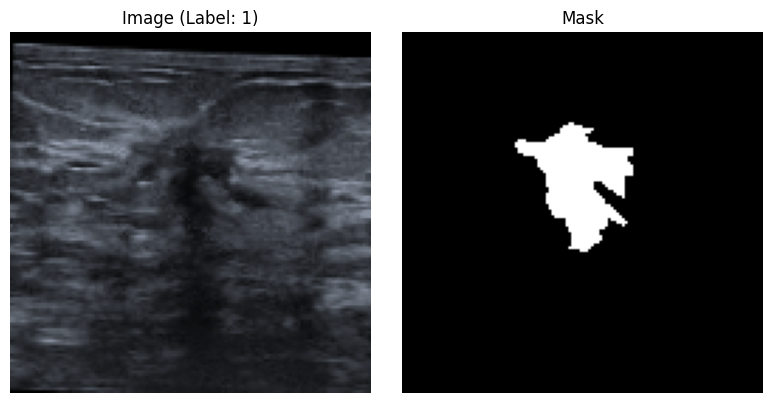

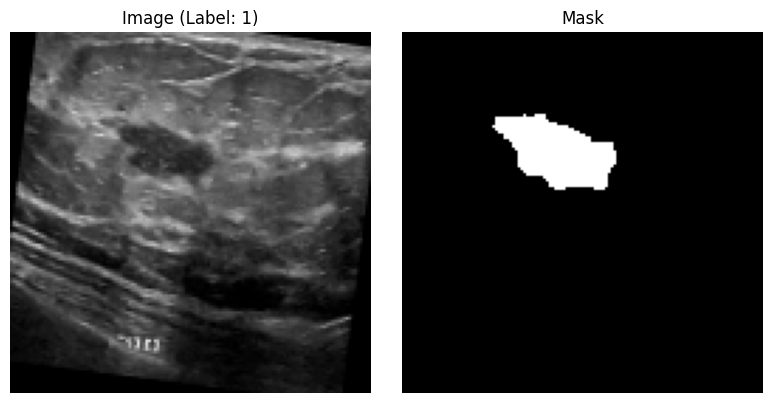

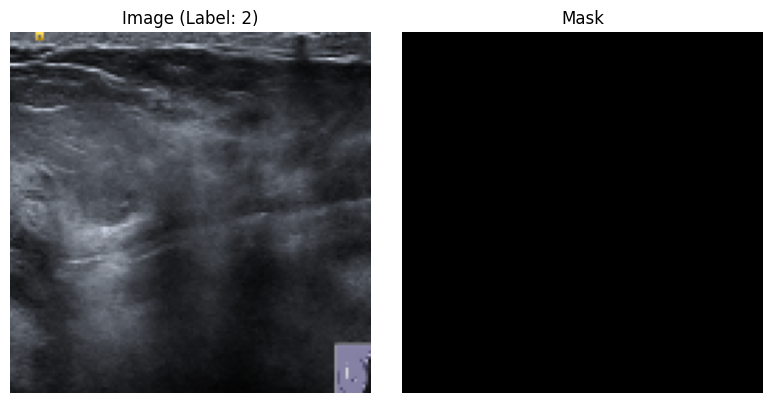

In [ ]:
# ===== VISUALIZE DATASET WITH DENORMALIZATION =====

import matplotlib.pyplot as plt
import random as rd
import torch

SEED = 20
rd.seed(SEED)

MEAN_vis = 0.5
STD_vis = 0.5

def denormalize(img, mean, std):
    """
    img: Tensor (C,H,W) normalized
    return: Tensor (C,H,W) in [0,1]
    """
    img = img.clone()
    img = img * std + mean
    return torch.clamp(img, 0, 1)

def show_examples(dataset, n=3):
    for i in range(n):
        idx = rd.randrange(len(dataset))
        img, mask, label = dataset[idx]

        # Denormalize image for display
        img = denormalize(img, MEAN_vis, STD_vis)

        img_np = img.permute(1, 2, 0).numpy()   # (C,H,W) -> (H,W,C)
        mask_np = mask.squeeze(0).numpy()       # (1,H,W) -> (H,W)

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))

        ax[0].imshow(img_np)
        ax[0].set_title(f"Image (Label: {label})")
        ax[0].axis('off')

        ax[1].imshow(mask_np, cmap='gray')
        ax[1].set_title("Mask")
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()

# Show examples
show_examples(FS_train_ds, n=3)


We can see in the visualisations that the dataset was correctly formed: each image is associated with the good mask (even with untrained eyes, we can see that the shapes correspond).

---

This next cell shows the repartition between the different classes in the training, validation and test sets.

**The proportion of each class should be the same in these 3 sets.** We can verify that with the prints.


=== Training ===
Classe B: 611 images (45.19%)
Classe M: 327 images (24.19%)
Classe N: 414 images (30.62%)

=== Validation ===
Classe B: 68 images (45.03%)
Classe M: 37 images (24.50%)
Classe N: 46 images (30.46%)


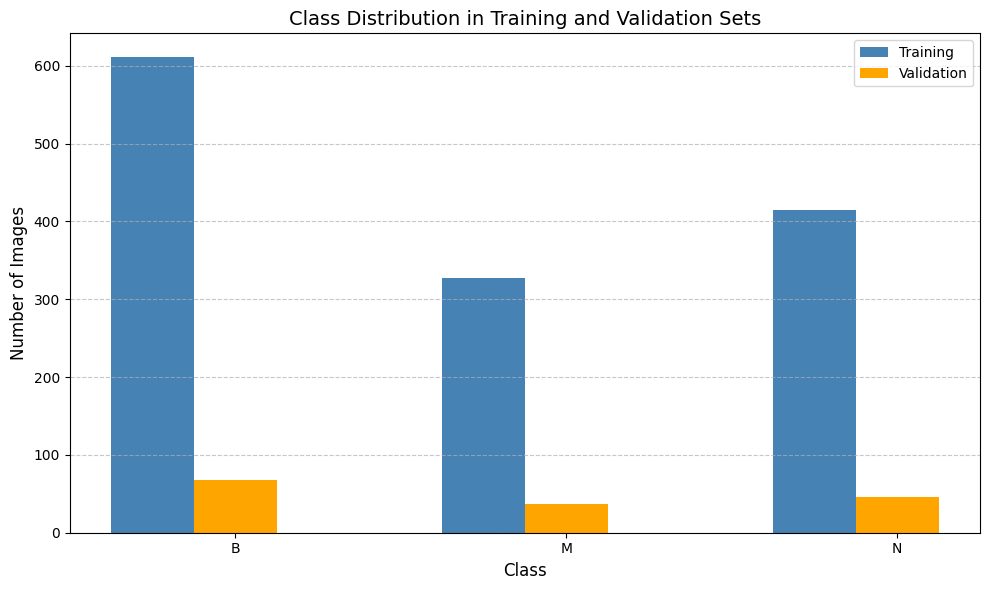

In [ ]:
# Count number of samples per class
train_counts = Counter(FS_train_ds.labels)
val_counts = Counter(FS_val_ds.labels)

# Define class names
class_names = ["B", "M", "N"]
num_classes = len(class_names)

# Convert counts to lists aligned with class_names order
train_values = [train_counts.get(i, 0) for i in range(num_classes)]
val_values = [val_counts.get(i, 0) for i in range(num_classes)]

def print_percentages(name, values):
    total = sum(values)
    print(f"\n=== {name} ===")
    for cls, count in zip(class_names, values):
        pct = (count / total * 100) if total > 0 else 0
        print(f"Classe {cls}: {count} images ({pct:.2f}%)")

print_percentages("Training", train_values)
print_percentages("Validation", val_values)

x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, train_values, width, label="Training", color="steelblue")
plt.bar(x, val_values, width, label="Validation", color="orange")

plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Class Distribution in Training and Validation Sets", fontsize=14)

plt.xticks(x, class_names)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


We do another visualisation of the images and the masks. However, this time, we look at 1 pair for each label/class. This means that this time we want to see (qualitatively, with our eyes) the differences between the different classes.

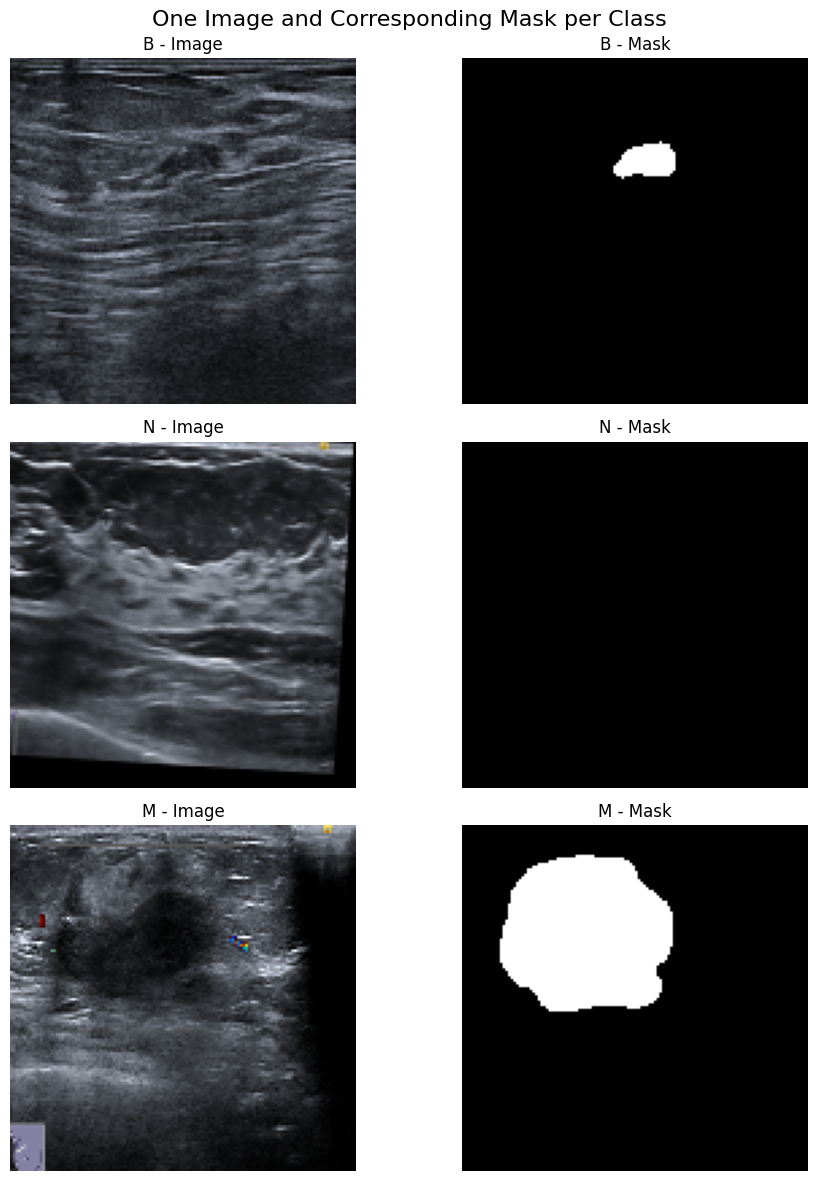

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ["B", "M", "N"]

# Collect one (image, mask) per class
samples_per_class = {}

for img, mask, label in FS_train_ds:
    cls = class_names[label]
    if cls not in samples_per_class:
        samples_per_class[cls] = (img, mask)
    if len(samples_per_class) == len(class_names):
        break

# Create figure: rows = classes, cols = [image | mask]
fig, axes = plt.subplots(
    nrows=len(class_names),
    ncols=2,
    figsize=(10, 4 * len(class_names))
)

for i, (cls, (img, mask)) in enumerate(samples_per_class.items()):

    # ---- Unnormalize image ----
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * STD[c] + MEAN[c]
    img = img.clamp(0, 1)

    img_np = img.numpy().transpose(1, 2, 0)   # CHW -> HWC
    mask_np = mask.squeeze(0).numpy()          # (H, W)

    # ---- Plot image ----
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{cls} - Image")
    axes[i, 0].axis("off")

    # ---- Plot mask ----
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title(f"{cls} - Mask")
    axes[i, 1].axis("off")

plt.suptitle("One Image and Corresponding Mask per Class", fontsize=16)
plt.tight_layout()
plt.show()


---
# **Classification**
---

This section **Classification** is dedicated to the exploration and experimentations of 2 classification models:
* a **CNN trained from scratch**
* a model with **transfer learning** based on ResNet50.


After the analysis of these 2 different models, we will choose the best performing model and use this one for the classification tasks.

---

# **Build CNN from scratch**

## Dataset preparation
We don't need to make another dataset preparation, the one done in the first section is good for the CNN from scratch (the normalization is the correct one).

## Model definition

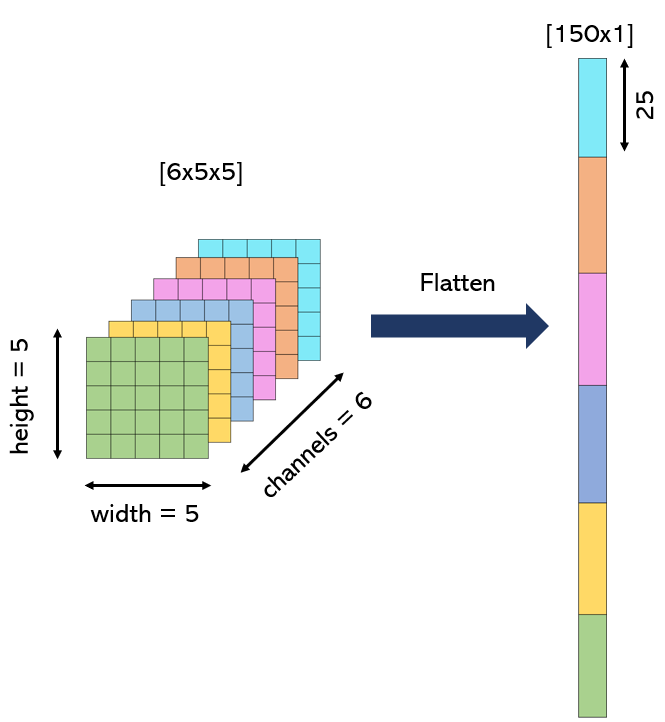

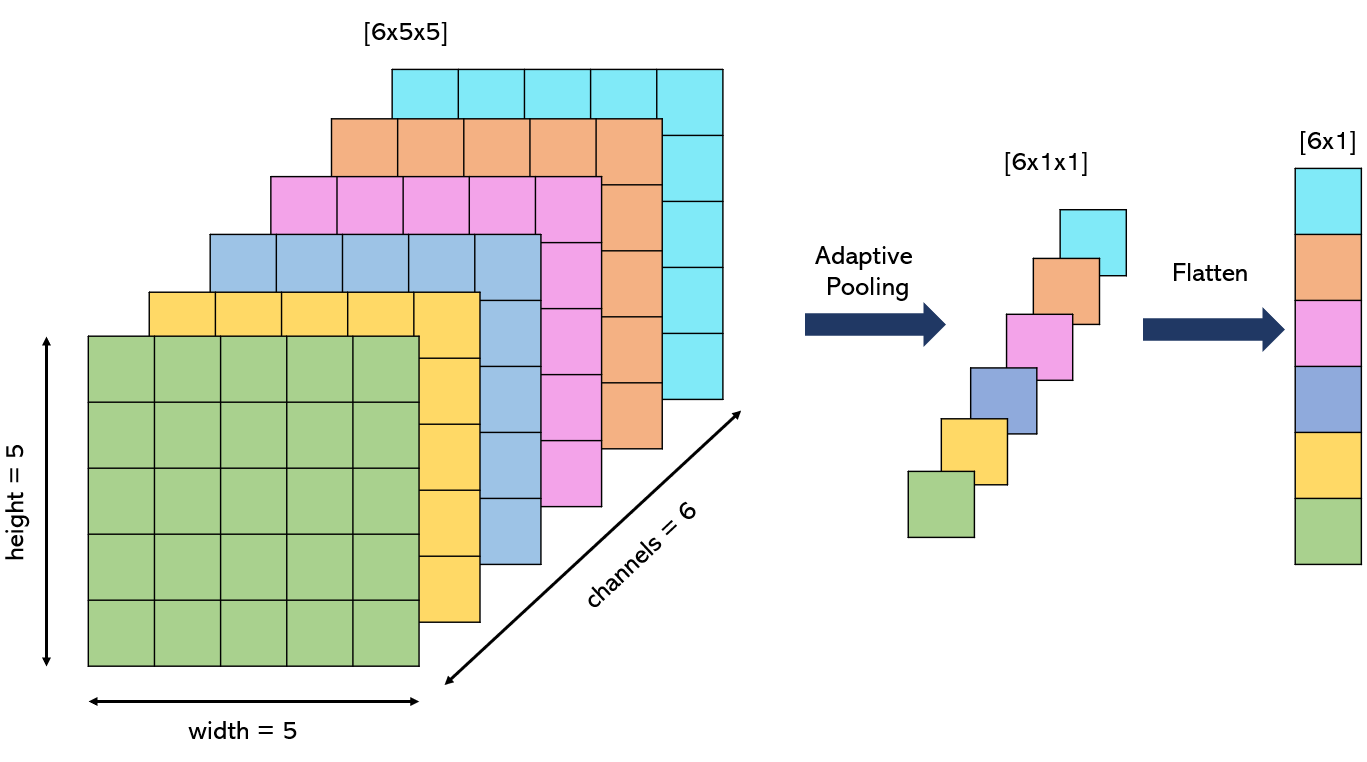

In [ ]:
class CNN_v1(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN_v1, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # after 3 pooling layers on 128x128 input size is 16x16 --> 128 channels * 16 height * 16 width
        self.fc1 = nn.Linear(in_features=32768, out_features=256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes) # 4 outputs neurons

    def forward(self, x):                     # input shape 3 x 128 x 128
        x = self.pool(F.relu(self.conv1(x)))  # conv --> 32 x 128 x 128 - pooling --> 32 x 64 x 64
        x = self.pool(F.relu(self.conv2(x)))  # conv --> 64 x 64 x 64  - pooling --> 64 x 32 x 32
        x = self.pool(F.relu(self.conv3(x)))  # conv --> 128 x 32 x 32 - pooling --> 128 x 16 x 16
        x = torch.flatten(x, 1)               # --> 32768 (128*16*16)
        x = F.relu(self.fc1(x))               # --> 256
        x = self.dropout(x)
        x = self.fc2(x)                       # --> 4 (num_classes)
        return x

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.global_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1)) # adaptive average pooling
        self.fc1 = nn.Linear(128, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes) # 4 outputs neurons

    def forward(self, x):                     # input shape 3 x 128 x 128
        x = self.pool(F.relu(self.conv1(x)))  # conv --> 3 x 128 x 128 - pooling --> 32 x 64 x 64
        x = self.pool(F.relu(self.conv2(x)))  # conv --> 64 x 64 x 64  - pooling --> 64 x 32 x 32
        x = self.pool(F.relu(self.conv3(x)))  # conv --> 128 x 32 x 32 - pooling --> 128 x 16 x 16
        x = self.global_pool(x)               # --> 128 x 1 x 1
        x = torch.flatten(x, 1)               # --> 128
        x = F.relu(self.fc1(x))               # --> 256
        x = self.dropout(x)
        x = self.fc2(x)                       # --> 4 (num_classes)
        return x


## Model training

In [ ]:
# Initialize the model
num_classes = 3
FS_model = CNN(num_classes=num_classes).to(device)

# Define weighted loss function
targets = np.array(FS_train_ds.labels)
class_counts = np.bincount(targets)
inv_freq = 1.0 / class_counts
inv_freq = inv_freq / inv_freq.sum()
# Enhancing clinical priority (Taking M as B is worst than taking B as N)
clinical_boost = np.array([1.0, 1.2, 2.0])
class_weights = inv_freq * clinical_boost
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [611 327 414]
Class weights: tensor([0.2302, 0.5161, 0.6794], device='cuda:0')


In [ ]:
# Define optimizer
optimizer = optim.Adam(FS_model.parameters(), lr=0.001)

# Reduce learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
early_stopping_patience = 10
best_val_loss = np.inf
epochs_no_improve = 0

# Max number of epochs
epochs = 100

In [ ]:
for epoch in range(epochs):

    # Training
    FS_model.train()
    running_loss = 0.0

    for inputs, masks, labels in FS_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = FS_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(FS_train_loader)

    # Validation
    FS_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, masks, labels in FS_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = FS_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / len(FS_val_loader)
    val_acc = 100 * correct / total

    # Step the scheduler
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = FS_model.state_dict()  # save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("Training complete. Best validation loss:", np.round(best_val_loss, 4))


Epoch [1/100] | Train Loss: 1.0615 | Val Loss: 1.0406 | Val Acc: 33.11%
Epoch [2/100] | Train Loss: 1.0307 | Val Loss: 1.0267 | Val Acc: 48.34%
Epoch [3/100] | Train Loss: 1.0129 | Val Loss: 1.0047 | Val Acc: 45.03%
Epoch [4/100] | Train Loss: 1.0007 | Val Loss: 0.9917 | Val Acc: 47.68%
Epoch [5/100] | Train Loss: 1.0083 | Val Loss: 0.9798 | Val Acc: 47.02%
Epoch [6/100] | Train Loss: 1.0019 | Val Loss: 0.9935 | Val Acc: 48.34%
Epoch [7/100] | Train Loss: 0.9854 | Val Loss: 0.9707 | Val Acc: 51.66%
Epoch [8/100] | Train Loss: 0.9714 | Val Loss: 0.9659 | Val Acc: 51.66%
Epoch [9/100] | Train Loss: 0.9798 | Val Loss: 0.9467 | Val Acc: 51.66%
Epoch [10/100] | Train Loss: 0.9539 | Val Loss: 0.9090 | Val Acc: 54.30%
Epoch [11/100] | Train Loss: 0.9522 | Val Loss: 0.9238 | Val Acc: 52.98%
Epoch [12/100] | Train Loss: 0.9572 | Val Loss: 0.9552 | Val Acc: 50.99%
Epoch [13/100] | Train Loss: 0.9484 | Val Loss: 0.9429 | Val Acc: 49.67%
Epoch [14/100] | Train Loss: 0.9443 | Val Loss: 0.9469 | Val

In [ ]:
# Save best model
torch.save(FS_model.state_dict(), r"/content/drive/MyDrive/results/cnn_from_scratch.pth")

## Model evaluation

In [ ]:
# Recreate th model
FS_model = CNN(num_classes=3)

# Load weights
FS_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/cnn_from_scratch.pth", map_location=device))
FS_model.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)

In [ ]:
def eval_model(data_loader, model, class_names=class_names):

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, masks, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


    # Visualize it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format=".1f")
    plt.title("Confusion Matrix - Classification")
    plt.show()

    # === Global metrics ===
    accuracy = correct / total

    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_per_class = f1_score(all_labels, all_preds, average=None)

    sensitivity_macro = recall_score(all_labels, all_preds, average='macro')
    sensitivity_weighted = recall_score(all_labels, all_preds, average='weighted')
    sensitivity_per_class = recall_score(all_labels, all_preds, average=None)

    # specificity has no built-in function thus it is computed manually
    specificity_per_class = []
    n_classes = len(class_names)
    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i]) # all elements except the ones on row i and column i
        fp = cm[:, i].sum() - cm[i, i] # column of the class
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    specificity_per_class = np.array(specificity_per_class)
    class_counts = np.bincount(all_labels)
    class_weights = class_counts / class_counts.sum()
    specificity_macro = specificity_per_class.mean()
    specificity_weighted = np.average(specificity_per_class, weights=class_weights)

    # === Display ===
    print("\n=== Global Metrics ===")
    print(f"Accuracy                  : {100 * accuracy:.2f}%")
    print(f"Balanced Accuracy         : {100 * balanced_acc:.2f}%")
    print(f"\nF1-score (Macro)          : {100 * f1_macro:.2f}%")
    print(f"F1-score (Weighted)       : {100 * f1_weighted:.2f}%")
    print(f"\nSensitivity (Macro)       : {100 * sensitivity_macro:.2f}%")
    print(f"Sensitivity (Weighted)    : {100 * sensitivity_weighted:.2f}%")
    print(f"\nSpecificity (Macro)       : {100 * specificity_macro:.2f}%")
    print(f"Specificity (Weighted)    : {100 * specificity_weighted:.2f}%")

    print("\n=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        print(f"{cls:20s} | "
            f"Accuracy: {100 * cm[i, i] / cm[i, :].sum():6.2f}% | "
            f"F1: {100 * f1_per_class[i]:6.2f}% | "
            f"Sensitivity: {100 * sensitivity_per_class[i]:6.2f}% | "
            f"Specificity: {100 * specificity_per_class[i]:6.2f}%")



    print("\n=== True vs Predicted Class Distribution ===")

    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)

    n_classes = len(class_names)

    pred_counts = np.bincount(all_preds_np, minlength=n_classes)
    true_counts = np.bincount(all_labels_np, minlength=n_classes)

    pred_percentages = pred_counts / pred_counts.sum() * 100
    true_percentages = true_counts / true_counts.sum() * 100

    print("\nClass-wise distribution:")
    for i, cls in enumerate(class_names):
        print(
            f"{cls:20s} | "
            f"True: {true_counts[i]:6d} ({true_percentages[i]:6.2f}%) | "
            f"Pred: {pred_counts[i]:6d} ({pred_percentages[i]:6.2f}%)"
        )

    # Plot side-by-side bar chart
    x = np.arange(n_classes)
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, true_counts, width, label="True labels")
    plt.bar(x + width / 2, pred_counts, width, label="Predicted labels")

    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.title("True vs Predicted Class Distribution")
    plt.xticks(x, class_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


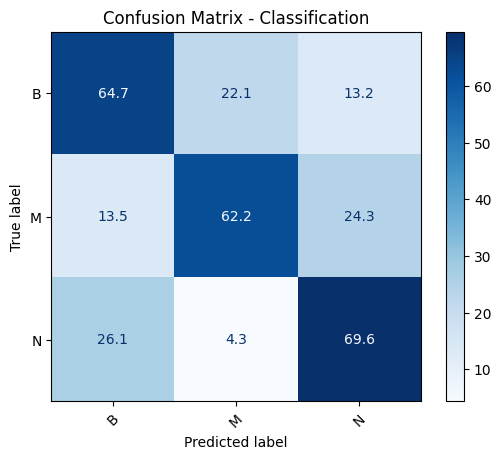


=== Global Metrics ===
Accuracy                  : 65.56%
Balanced Accuracy         : 65.48%

F1-score (Macro)          : 64.87%
F1-score (Weighted)       : 65.67%

Sensitivity (Macro)       : 65.48%
Sensitivity (Weighted)    : 65.56%

Specificity (Macro)       : 82.49%
Specificity (Weighted)    : 81.90%

=== Per-Class Metrics ===
B                    | Accuracy:  64.71% | F1:  68.22% | Sensitivity:  64.71% | Specificity:  79.52%
M                    | Accuracy:  62.16% | F1:  59.74% | Sensitivity:  62.16% | Specificity:  85.09%
N                    | Accuracy:  69.57% | F1:  66.67% | Sensitivity:  69.57% | Specificity:  82.86%

=== True vs Predicted Class Distribution ===

Class-wise distribution:
B                    | True:     68 ( 45.03%) | Pred:     61 ( 40.40%)
M                    | True:     37 ( 24.50%) | Pred:     40 ( 26.49%)
N                    | True:     46 ( 30.46%) | Pred:     50 ( 33.11%)


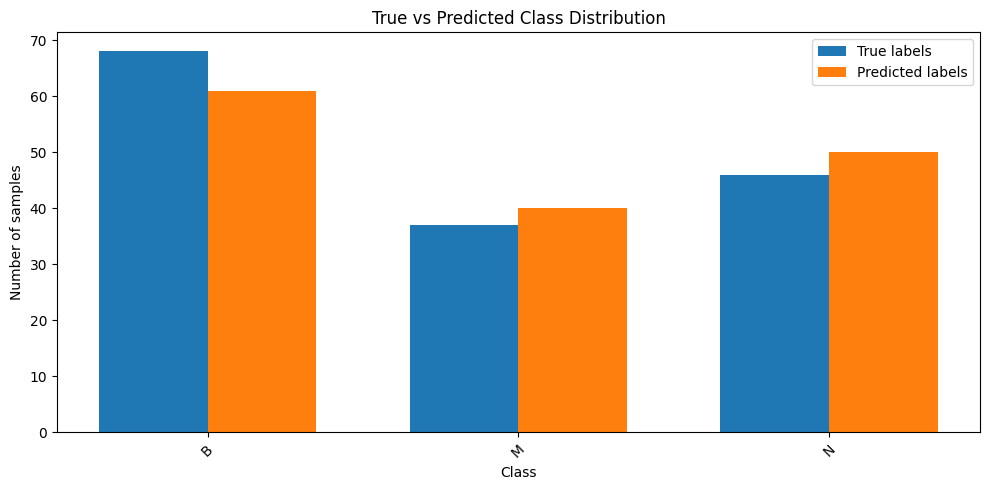

In [ ]:
eval_model(FS_val_loader, FS_model)

## New training

In [ ]:
# Define model
num_classes = 3
FS_model = CNN(num_classes=num_classes).to(device)

# Define loss function
criterion = nn.CrossEntropyLoss() # NO CLASS WEIGHTS

# Define optimizer
optimizer = optim.Adam(FS_model.parameters(), lr=0.001)

# Reduce learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
early_stopping_patience = 10
best_val_loss = np.inf
epochs_no_improve = 0

# Max number of epochs
epochs = 100

In [ ]:
for epoch in range(epochs):

    # Training
    FS_model.train()
    running_loss = 0.0

    for inputs, masks, labels in FS_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = FS_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(FS_train_loader)

    # Validation
    FS_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, masks, labels in FS_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = FS_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / len(FS_val_loader)
    val_acc = 100 * correct / total

    # Step the scheduler
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = FS_model.state_dict()  # save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best weights
print("Training complete. Best validation loss:", np.round(best_val_loss, 4))


Epoch [1/100] | Train Loss: 1.0535 | Val Loss: 1.0262 | Val Acc: 43.05%
Epoch [2/100] | Train Loss: 1.0342 | Val Loss: 1.0195 | Val Acc: 45.03%
Epoch [3/100] | Train Loss: 1.0316 | Val Loss: 1.0131 | Val Acc: 44.37%
Epoch [4/100] | Train Loss: 1.0130 | Val Loss: 0.9991 | Val Acc: 51.66%
Epoch [5/100] | Train Loss: 1.0155 | Val Loss: 0.9976 | Val Acc: 48.34%
Epoch [6/100] | Train Loss: 0.9948 | Val Loss: 0.9808 | Val Acc: 54.97%
Epoch [7/100] | Train Loss: 0.9984 | Val Loss: 0.9639 | Val Acc: 54.97%
Epoch [8/100] | Train Loss: 0.9832 | Val Loss: 0.9745 | Val Acc: 54.30%
Epoch [9/100] | Train Loss: 0.9843 | Val Loss: 0.9588 | Val Acc: 53.64%
Epoch [10/100] | Train Loss: 0.9749 | Val Loss: 0.9340 | Val Acc: 55.63%
Epoch [11/100] | Train Loss: 0.9638 | Val Loss: 0.9377 | Val Acc: 60.93%
Epoch [12/100] | Train Loss: 0.9620 | Val Loss: 0.9307 | Val Acc: 55.63%
Epoch [13/100] | Train Loss: 0.9648 | Val Loss: 0.9210 | Val Acc: 57.62%
Epoch [14/100] | Train Loss: 0.9406 | Val Loss: 0.8971 | Val

In [ ]:
# Save best model
torch.save(FS_model.state_dict(), r"/content/drive/MyDrive/results/cnn_from_scratch_nocw.pth")

## Model evaluation

In [ ]:
# Recreate th model
FS_model = CNN(num_classes=3)

# Load weights
FS_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/cnn_from_scratch_nocw.pth", map_location=device))
FS_model.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)

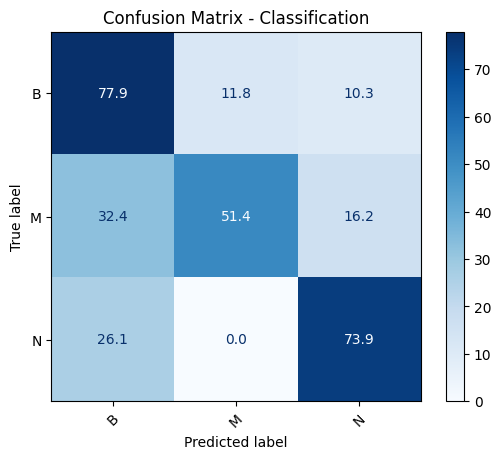


=== Global Metrics ===
Accuracy                  : 70.20%
Balanced Accuracy         : 67.74%

F1-score (Macro)          : 68.53%
F1-score (Weighted)       : 69.74%

Sensitivity (Macro)       : 67.74%
Sensitivity (Weighted)    : 70.20%

Specificity (Macro)       : 83.90%
Specificity (Weighted)    : 81.49%

=== Per-Class Metrics ===
B                    | Accuracy:  77.94% | F1:  73.10% | Sensitivity:  77.94% | Specificity:  71.08%
M                    | Accuracy:  51.35% | F1:  59.38% | Sensitivity:  51.35% | Specificity:  92.98%
N                    | Accuracy:  73.91% | F1:  73.12% | Sensitivity:  73.91% | Specificity:  87.62%

=== True vs Predicted Class Distribution ===

Class-wise distribution:
B                    | True:     68 ( 45.03%) | Pred:     77 ( 50.99%)
M                    | True:     37 ( 24.50%) | Pred:     27 ( 17.88%)
N                    | True:     46 ( 30.46%) | Pred:     47 ( 31.13%)


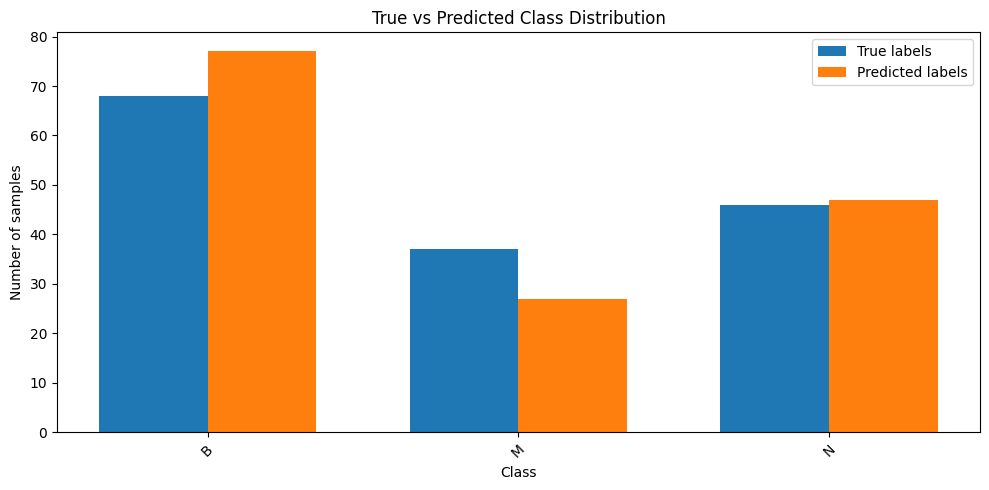

In [ ]:
eval_model(FS_val_loader, FS_model)

# **Transfer learning**

## Dataset preparation
The transfer learning needs another normalisation than the CNN from scratch. This means that we have to create another dataset with another normalization (the ImageNet normalization).

In [ ]:
IMG_SIZE = (224, 224)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
TL_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = train_transform_IN
)

TL_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = val_transform_IN
)


### Create dataloaders

# define batch size
batch_size = 32

TL_train_loader = DataLoader(TL_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
TL_val_loader = DataLoader(TL_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(TL_train_ds)+len(TL_val_ds)}")
print(f"Training set: {len(TL_train_ds)}")
print(f"Validation set: {len(TL_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151



=== Training ===
Classe B: 611 images (45.19%)
Classe M: 327 images (24.19%)
Classe N: 414 images (30.62%)

=== Validation ===
Classe B: 68 images (45.03%)
Classe M: 37 images (24.50%)
Classe N: 46 images (30.46%)


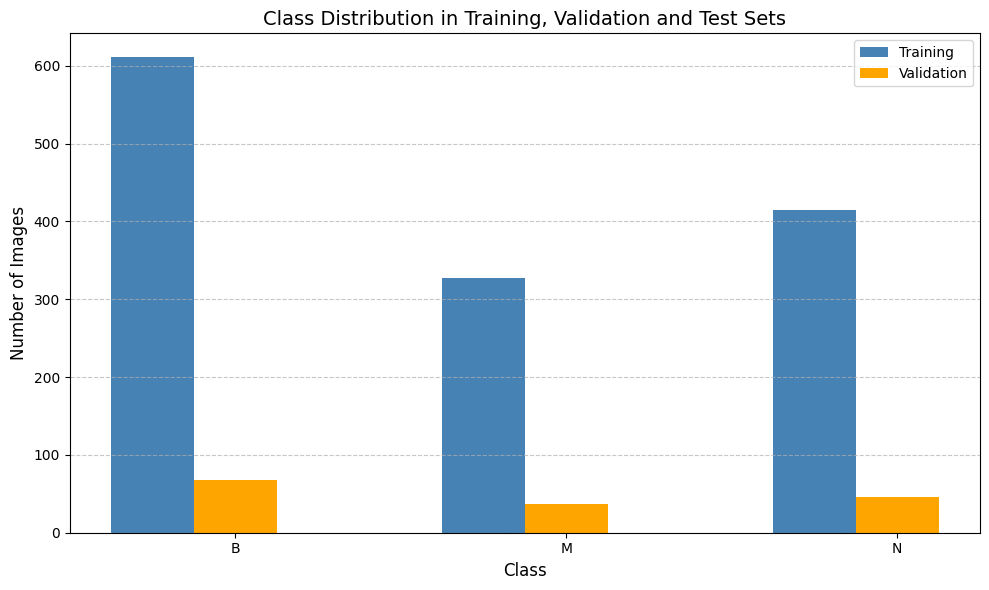

In [ ]:
# Count number of samples per class
train_counts = Counter(TL_train_ds.labels)
val_counts = Counter(TL_val_ds.labels)

# Define class names
class_names = ["B", "M", "N"]
num_classes = len(class_names)

# Convert counts to lists aligned with class_names order
train_values = [train_counts.get(i, 0) for i in range(num_classes)]
val_values = [val_counts.get(i, 0) for i in range(num_classes)]


def print_percentages(name, values):
    total = sum(values)
    print(f"\n=== {name} ===")
    for cls, count in zip(class_names, values):
        pct = (count / total * 100) if total > 0 else 0
        print(f"Classe {cls}: {count} images ({pct:.2f}%)")

print_percentages("Training", train_values)
print_percentages("Validation", val_values)
# -------------------------------------------------

x = np.arange(num_classes)
width = 0.25  # plus fin car 3 barres

plt.figure(figsize=(10, 6))

plt.bar(x - width, train_values, width, label="Training", color="steelblue")
plt.bar(x, val_values, width, label="Validation", color="orange")

plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Class Distribution in Training, Validation and Test Sets", fontsize=14)

plt.xticks(x, class_names)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()




In [ ]:
# Get one batch from the training loader
images, masks, labels = next(iter(TL_train_loader))

print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")

# Check a single image shape
print(f"Single image shape: {images[0].shape}")

Images batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])
Single image shape: torch.Size([3, 224, 224])


In [ ]:
# 1. Grab a single batch
images, masks,_ = next(iter(TL_train_loader))

# 2. Check statistics
img_min, img_max = images.min().item(), images.max().item()
img_mean, img_std = images.mean().item(), images.std().item()

print(f"Tensor Shape: {images.shape}")
print(f"Data Range:   [{img_min:.3f}, {img_max:.3f}]")
print(f"Mean/Std:     {img_mean:.3f} / {img_std:.3f}")

# 3. Validation Logic
if img_max > 5.0:
    print("STATUS: Raw pixels detected (0-255). No normalization.")
elif img_min >= 0.0 and img_max <= 1.0:
    print("STATUS: 0-1 range detected.")
else:
    print("STATUS: Normalized range detected (Standard for ImageNet).")

Tensor Shape: torch.Size([32, 3, 224, 224])
Data Range:   [-2.118, 2.640]
Mean/Std:     -0.704 / 0.931
STATUS: Normalized range detected (Standard for ImageNet).


## Model definition

In [ ]:
# Load pretrained ResNet50
TL_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all convolutional layers
for param in TL_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_features = TL_model.fc.in_features
TL_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

TL_model = TL_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 80.5MB/s]


## Model training

In [ ]:
# Define loss function
targets = np.array(TL_train_ds.labels)
class_counts = np.bincount(targets)
inv_freq = 1.0 / class_counts
inv_freq = inv_freq / inv_freq.sum()
# Enhancing clinical priority (Taking M as B is worst than taking B as N)
clinical_boost = np.array([1.0, 1.2, 2.0])
class_weights = inv_freq * clinical_boost
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Define optimizer
optimizer = optim.Adam(TL_model.parameters(), lr=0.001)

# Reduce learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
early_stopping_patience = 10
best_val_loss = np.inf
epochs_no_improve = 0

# Max number of epochs
epochs = 100

for epoch in range(epochs):

    # Training
    TL_model.train()
    running_loss = 0.0

    for inputs, masks, labels in TL_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = TL_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(TL_train_loader)

    # Validation
    TL_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, masks, labels in TL_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = TL_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / len(TL_val_loader)
    val_acc = 100 * correct / total

    # Step the scheduler
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = TL_model.state_dict()  # save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best weights
TL_model.load_state_dict(best_model_wts)
print("Training complete. Best validation loss:", np.round(best_val_loss, 4))



Epoch [1/100] | Train Loss: 0.9108 | Val Loss: 0.8209 | Val Acc: 53.64%
Epoch [2/100] | Train Loss: 0.8039 | Val Loss: 0.7530 | Val Acc: 60.26%
Epoch [3/100] | Train Loss: 0.7314 | Val Loss: 0.7929 | Val Acc: 58.28%
Epoch [4/100] | Train Loss: 0.6824 | Val Loss: 0.6544 | Val Acc: 72.85%
Epoch [5/100] | Train Loss: 0.6489 | Val Loss: 0.6881 | Val Acc: 62.91%
Epoch [6/100] | Train Loss: 0.6062 | Val Loss: 0.6472 | Val Acc: 66.23%
Epoch [7/100] | Train Loss: 0.6241 | Val Loss: 0.6859 | Val Acc: 66.23%
Epoch [8/100] | Train Loss: 0.5982 | Val Loss: 0.6434 | Val Acc: 68.21%
Epoch [9/100] | Train Loss: 0.5616 | Val Loss: 0.6447 | Val Acc: 68.87%
Epoch [10/100] | Train Loss: 0.5314 | Val Loss: 0.6455 | Val Acc: 66.23%
Epoch [11/100] | Train Loss: 0.5659 | Val Loss: 0.6387 | Val Acc: 64.90%
Epoch [12/100] | Train Loss: 0.5631 | Val Loss: 0.6203 | Val Acc: 74.83%
Epoch [13/100] | Train Loss: 0.5285 | Val Loss: 0.6143 | Val Acc: 72.19%
Epoch [14/100] | Train Loss: 0.5211 | Val Loss: 0.6461 | Val

In [ ]:
# Save best model
torch.save(TL_model.state_dict(), r"/content/drive/MyDrive/results/transfer_learning.pth")

## Model evaluation

In [ ]:
# Recreate th model
TL_model = models.resnet50(weights=None)  # no pretrained weights this time
num_features = TL_model.fc.in_features
TL_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

# Load weights
TL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/transfer_learning.pth", map_location=device))
TL_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

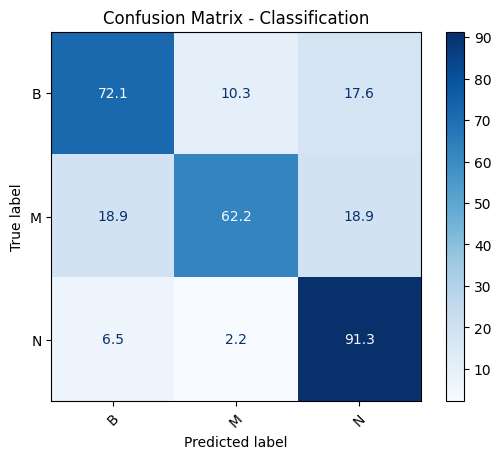


=== Global Metrics ===
Accuracy                  : 75.50%
Balanced Accuracy         : 75.18%

F1-score (Macro)          : 74.44%
F1-score (Weighted)       : 75.24%

Sensitivity (Macro)       : 75.18%
Sensitivity (Weighted)    : 75.50%

Specificity (Macro)       : 87.61%
Specificity (Weighted)    : 87.34%

=== Per-Class Metrics ===
B                    | Accuracy:  72.06% | F1:  77.17% | Sensitivity:  72.06% | Specificity:  87.95%
M                    | Accuracy:  62.16% | F1:  67.65% | Sensitivity:  62.16% | Specificity:  92.98%
N                    | Accuracy:  91.30% | F1:  78.50% | Sensitivity:  91.30% | Specificity:  81.90%

=== True vs Predicted Class Distribution ===

Class-wise distribution:
B                    | True:     68 ( 45.03%) | Pred:     59 ( 39.07%)
M                    | True:     37 ( 24.50%) | Pred:     31 ( 20.53%)
N                    | True:     46 ( 30.46%) | Pred:     61 ( 40.40%)


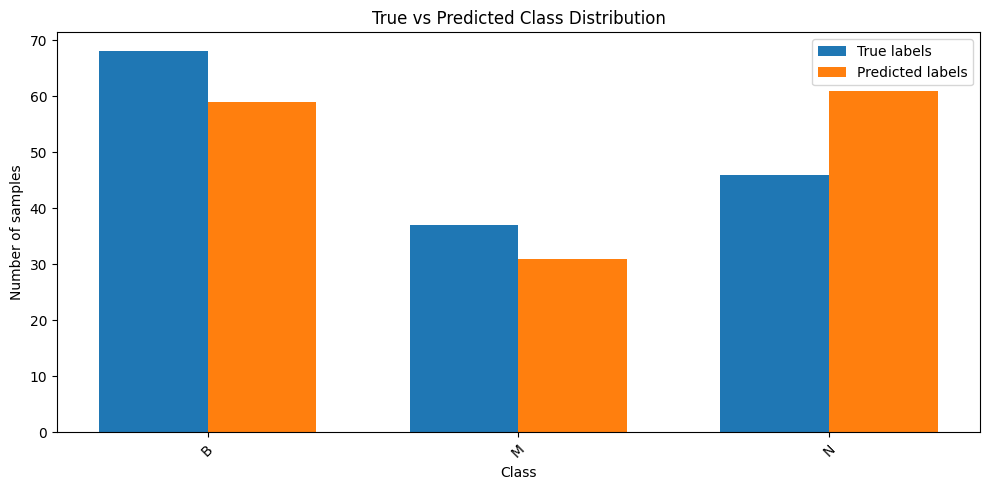

In [ ]:
eval_model(TL_val_loader, TL_model)

---
# **Segmentation**
---

This section **Segmentation** is dedicated to the exploration and experimentations of 4 segmentation models:
* **U-Net from scratch**
* **MaNet**
* **DeepLabV3**
* **SegFormer**


After the analysis of these 4 different models, we will choose the best performing model and use this one for the segmentation tasks.

---

# Helper functions

In [ ]:
def dice_coefficient(preds, targets, smooth=1e-6):
    # preds and targets are torch tensors with shape [B, 1, H, W]
    preds = (preds > 0.5).float()  # binarize predictions
    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean().item()  # mean over batch

def dice_score(pred, target, smooth=1e-6):
    """Computes Dice coefficient for binary masks."""
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    """Computes Intersection over Union (Jaccard index)."""
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# U-Net from scratch

## Dataset preparation

In [ ]:
IMG_SIZE = (224, 224)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# The U-Net from scratch doens't need normalization
TEMP_MEAN=[0, 0, 0]
TEMP_STD=[1, 1, 1]

UN_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = get_train_transform(IMG_SIZE, TEMP_MEAN, TEMP_STD)
)

UN_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = get_val_transform(IMG_SIZE, TEMP_MEAN, TEMP_STD)
)


### Create dataloaders

# define batch size
batch_size = 32

UN_train_loader = DataLoader(UN_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
UN_val_loader = DataLoader(UN_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(UN_train_ds)+len(UN_val_ds)}")
print(f"Training set: {len(UN_train_ds)}")
print(f"Validation set: {len(UN_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151


In [ ]:
imgs, masks, labels = next(iter(UN_train_loader))
print(imgs.shape)  # should be (batch_size, C, H, W)
print(masks.shape) # should be (batch_size, C, H, W)

torch.Size([32, 3, 224, 224])
torch.Size([32, 1, 224, 224])


In [ ]:
# 1. Grab a single batch
images, masks,_ = next(iter(UN_train_loader))

# 2. Check statistics
img_min, img_max = images.min().item(), images.max().item()
img_mean, img_std = images.mean().item(), images.std().item()

print(f"Tensor Shape: {images.shape}")
print(f"Data Range:   [{img_min:.3f}, {img_max:.3f}]")
print(f"Mean/Std:     {img_mean:.3f} / {img_std:.3f}")

# 3. Validation Logic
if img_max > 5.0:
    print("STATUS: Raw pixels detected (0-255). No normalization.")
elif img_min >= 0.0 and img_max <= 1.0:
    print("STATUS: 0-1 range detected.")
else:
    print("STATUS: Normalized range detected (Standard for ImageNet).")

Tensor Shape: torch.Size([32, 3, 224, 224])
Data Range:   [0.000, 1.000]
Mean/Std:     0.284 / 0.206
STATUS: 0-1 range detected.


## Model definition

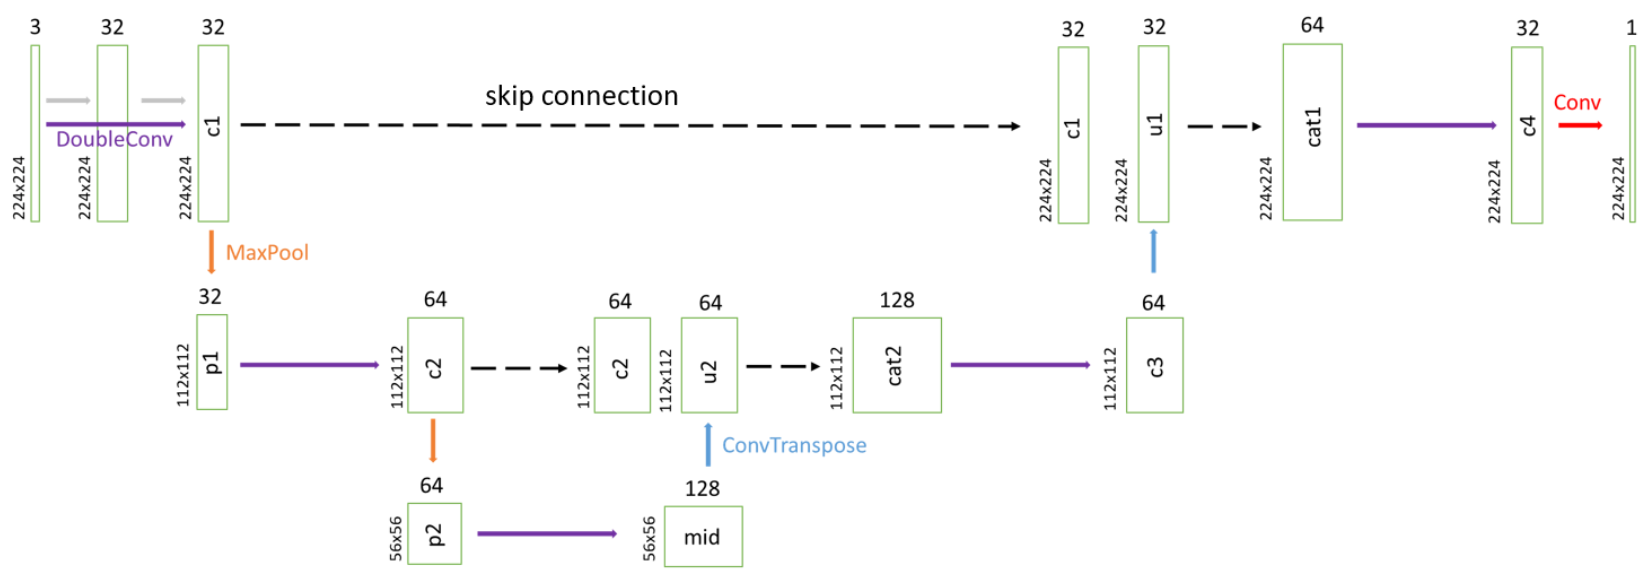

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class BasicUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(BasicUNet, self).__init__()
        self.down1 = DoubleConv(n_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.middle = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)
        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        mid = self.middle(p2)

        u2 = self.up2(mid)
        cat2 = torch.cat([u2, c2], dim=1)
        c3 = self.conv2(cat2)

        u1 = self.up1(c3)
        cat1 = torch.cat([u1, c1], dim=1)
        c4 = self.conv1(cat1)

        out = self.out_conv(c4)
        return torch.sigmoid(out)  # output between 0 and 1


## Model training

In [ ]:
# --- Model initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
UN_model = BasicUNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(UN_model.parameters(), lr=1e-3)

# --- Scheduler & Early stopping ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
patience = 10
best_val_loss = float("inf")
epochs_no_improve = 0

# --- Training loop ---
n_epochs = 100
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(n_epochs):
    # ---------------- TRAIN ----------------
    UN_model.train()
    train_loss = 0.0
    train_dice = 0.0
    loop = tqdm(UN_train_loader, total=len(UN_train_loader), desc=f"Epoch [{epoch+1}/{n_epochs}]")

    for imgs, masks, labels in loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = UN_model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        dice_coef = dice_coefficient(outputs, masks)
        train_dice += dice_coef

        loop.set_postfix(loss=loss.item(), dice=dice_coef)

    train_loss /= len(UN_train_loader)
    train_dice /= len(UN_train_loader)
    train_losses.append(train_loss)
    train_dices.append(train_dice)

    # ---------------- VALIDATION ----------------
    UN_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, labels in UN_val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = UN_model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks)

    val_loss /= len(UN_val_loader)
    val_dice /= len(UN_val_loader)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    # ---------------- EARLY STOPPING ----------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(UN_model.state_dict(), r"/content/drive/MyDrive/results/best_model_unet.pth")
        print("💾 Saved new best model.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break


cuda


Epoch [1/100]: 100%|██████████| 43/43 [00:23<00:00,  1.83it/s, dice=0.125, loss=0.438]



Epoch [1/100] | Train Loss: 0.5083 | Train Dice: 0.1466 | Val Loss: 0.4740 | Val Dice: 0.1272
💾 Saved new best model.


Epoch [2/100]: 100%|██████████| 43/43 [00:22<00:00,  1.91it/s, dice=0.533, loss=0.254]



Epoch [2/100] | Train Loss: 0.3487 | Train Dice: 0.2529 | Val Loss: 0.2995 | Val Dice: 0.3025
💾 Saved new best model.


...


Epoch [40/100] | Train Loss: 0.1345 | Train Dice: 0.4555 | Val Loss: 0.1301 | Val Dice: 0.4612
No improvement for 8 epoch(s).


Epoch [41/100]: 100%|██████████| 43/43 [00:22<00:00,  1.89it/s, dice=0.45, loss=0.136]



Epoch [41/100] | Train Loss: 0.1338 | Train Dice: 0.4605 | Val Loss: 0.1287 | Val Dice: 0.4475
No improvement for 9 epoch(s).


Epoch [42/100]: 100%|██████████| 43/43 [00:21<00:00,  1.99it/s, dice=0.551, loss=0.175]



Epoch [42/100] | Train Loss: 0.1328 | Train Dice: 0.4735 | Val Loss: 0.1289 | Val Dice: 0.4224
No improvement for 10 epoch(s).
🛑 Early stopping triggered!


## Model evaluation

cuda


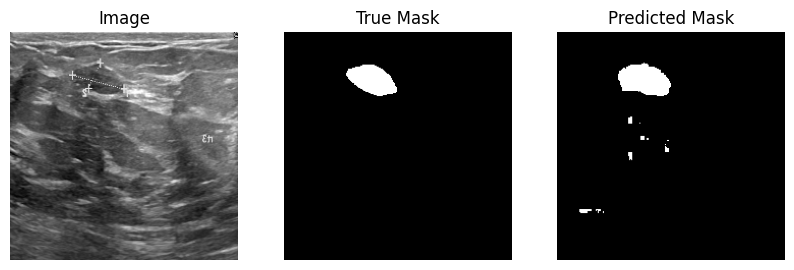

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
UN_model = BasicUNet().to(device)
UN_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_unet.pth"))

UN_model.eval()
with torch.no_grad():
    img, true_mask, label = UN_train_ds[24]
    input_tensor = img.unsqueeze(0).to(device)
    output = UN_model(input_tensor)
    pred_mask = output[0,0].cpu().numpy()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores(dataset):
    dice_scores = []
    iou_scores = []

    UN_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = UN_model(input_tensor)
            pred_mask = output[0, 0].cpu().numpy()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # Compute metrics
            dice = dice_score(pred_bin, true_bin)
            iou = iou_score(pred_bin, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---
    print("")
    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")


In [ ]:
print("TRAINING")
predict_scores(UN_train_ds)
print("\nVALIDATION")
predict_scores(UN_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [00:28<00:00, 47.62it/s]



Mean Dice Score: 0.54
Mean IoU Score:  0.47

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:02<00:00, 50.59it/s]


Mean Dice Score: 0.51
Mean IoU Score:  0.43


cuda


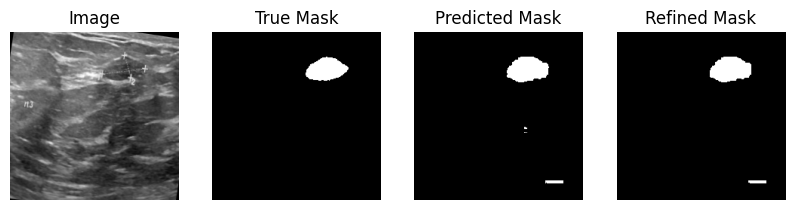

In [ ]:
from scipy import ndimage as ndi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
UN_model = BasicUNet().to(device)
UN_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_unet.pth"))

UN_model.eval()
with torch.no_grad():
    img, true_mask, label = UN_train_ds[101]
    input_tensor = img.unsqueeze(0).to(device)
    output = UN_model(input_tensor)
    pred_mask = output[0,0].cpu().numpy()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

# --- Morphological refinement ---
filled_mask = ndi.binary_fill_holes(binary_mask)        # fill internal holes
clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps

refined_mask = clean_mask.astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,4,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(refined_mask, cmap="gray"); plt.title("Refined Mask"); plt.axis("off")
plt.show()

In [ ]:
def predict_scores_new(dataset):
    dice_scores = []
    iou_scores = []

    UN_model.eval()
    with torch.no_grad():
        for img, true_mask, lab in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = UN_model(input_tensor)
            pred_mask = output[0, 0].cpu().numpy()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # --- Morphological refinement ---
            filled_mask = ndi.binary_fill_holes(pred_bin)        # fill internal holes
            clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
            clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps
            refined_mask = clean_mask.astype("uint8")

            # Compute metrics
            dice = dice_score(refined_mask, true_bin)
            iou = iou_score(refined_mask, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")


In [ ]:
print("TRAINING")
predict_scores_new(UN_train_ds)
print("\nVALIDATION")
predict_scores_new(UN_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [00:38<00:00, 34.98it/s]


Mean Dice Score: 0.59
Mean IoU Score:  0.51

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:03<00:00, 38.02it/s]

Mean Dice Score: 0.55
Mean IoU Score:  0.47


# MaNET

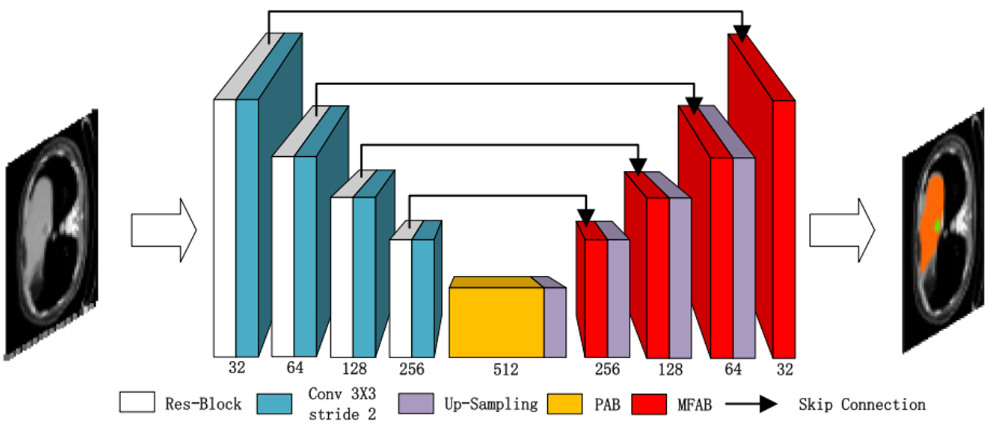

## Dataset preparation

In [ ]:
IMG_SIZE = (512, 512)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


In [ ]:
MA_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = train_transform_IN
)

MA_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = val_transform_IN
)


### Create dataloaders

# define batch size
batch_size = 32

MA_train_loader = DataLoader(MA_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
MA_val_loader = DataLoader(MA_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(MA_train_ds)+len(MA_val_ds)}")
print(f"Training set: {len(MA_train_ds)}")
print(f"Validation set: {len(MA_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151


In [ ]:
imgs, masks, labels = next(iter(MA_train_loader))
print(imgs.shape)  # should be (batch_size, C, H, W)
print(masks.shape) # should be (batch_size, C, H, W)


torch.Size([32, 3, 512, 512])
torch.Size([32, 1, 512, 512])


In [ ]:
# 1. Grab a single batch
images, masks,_ = next(iter(MA_train_loader))

# 2. Check statistics
img_min, img_max = images.min().item(), images.max().item()
img_mean, img_std = images.mean().item(), images.std().item()

print(f"Tensor Shape: {images.shape}")
print(f"Data Range:   [{img_min:.3f}, {img_max:.3f}]")
print(f"Mean/Std:     {img_mean:.3f} / {img_std:.3f}")

# 3. Validation Logic
if img_max > 5.0:
    print("STATUS: Raw pixels detected (0-255). No normalization.")
elif img_min >= 0.0 and img_max <= 1.0:
    print("STATUS: 0-1 range detected.")
else:
    print("STATUS: Normalized range detected (Standard for ImageNet).")

Tensor Shape: torch.Size([32, 3, 512, 512])
Data Range:   [-2.118, 2.640]
Mean/Std:     -0.771 / 0.902
STATUS: Normalized range detected (Standard for ImageNet).


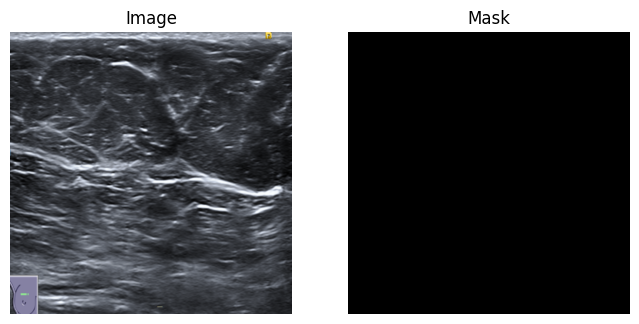

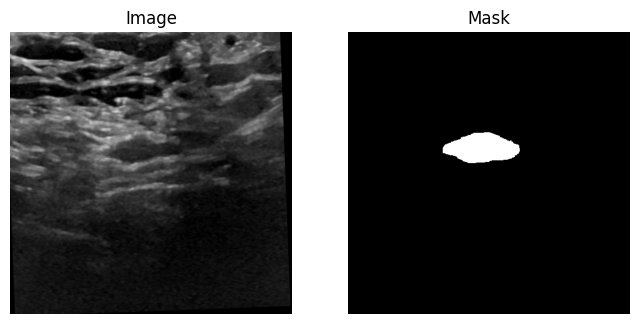

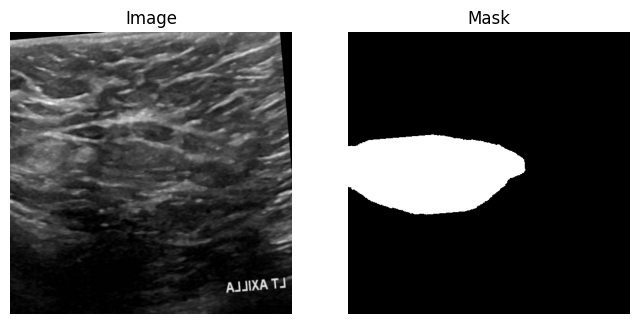

In [ ]:
import matplotlib.pyplot as plt

def show_examples(dataset, n=3):
    for i in range(n):
        img, mask, label = dataset[i+10]
        img = img.clone()
        for c in range(3):
            img[c] = img[c] * IN_STD[c] + IN_MEAN[c]

        img_np = img.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
        mask_np = mask.squeeze(0).numpy()      # (1,H,W) -> (H,W)

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(img_np)
        ax[0].set_title("Image")
        ax[0].axis('off')

        ax[1].imshow(mask_np, cmap='gray')
        ax[1].set_title("Mask")
        ax[1].axis('off')

        plt.show()

# Show 3 examples from the training dataset
show_examples(MA_train_ds, n=3)


### Model definition

In [ ]:
import segmentation_models_pytorch as smp

# Binary segmentation -> classes=1
MA_model = smp.MAnet(
    encoder_name="mit_b0",       # small transformer backbone
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

### Model training

In [ ]:
# --- Model initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
MA_model = MA_model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(MA_model.parameters(), lr=1e-4)

# --- Scheduler & Early stopping ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
patience = 5
best_val_loss = float("inf")
epochs_no_improve = 0

# --- Training loop ---
n_epochs = 100
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(n_epochs):
    # ---------------- TRAIN ----------------
    MA_model.train()
    train_loss = 0.0
    train_dice = 0.0
    loop = tqdm(MA_train_loader, total=len(MA_train_loader), desc=f"Epoch [{epoch+1}/{n_epochs}]")

    for imgs, masks, labels in loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = MA_model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coefficient(outputs, masks)

        loop.set_postfix(loss=loss.item(), dice=dice_coefficient(outputs, masks))

    train_loss /= len(MA_train_loader)
    train_dice /= len(MA_train_loader)
    train_losses.append(train_loss)
    train_dices.append(train_dice)

    # ---------------- VALIDATION ----------------
    MA_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, labels in MA_val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = MA_model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks)

    val_loss /= len(MA_val_loader)
    val_dice /= len(MA_val_loader)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    # ---------------- EARLY STOPPING ----------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(MA_model.state_dict(), r"/content/drive/MyDrive/results/best_model_manet.pth")
        print("💾 Saved new best model.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break


cuda


Epoch [1/100]: 100%|██████████| 43/43 [01:32<00:00,  2.16s/it, dice=0.514, loss=0.329]



Epoch [1/100] | Train Loss: 0.3877 | Train Dice: 0.3943 | Val Loss: 0.2818 | Val Dice: 0.3178
💾 Saved new best model.


Epoch [2/100]: 100%|██████████| 43/43 [01:30<00:00,  2.10s/it, dice=0.535, loss=0.255]



Epoch [2/100] | Train Loss: 0.2865 | Train Dice: 0.5277 | Val Loss: 0.2487 | Val Dice: 0.4794
💾 Saved new best model.


...


Epoch [20/100] | Train Loss: 0.0611 | Train Dice: 0.7972 | Val Loss: 0.0742 | Val Dice: 0.7652
No improvement for 3 epoch(s).


Epoch [21/100]: 100%|██████████| 43/43 [01:30<00:00,  2.11s/it, dice=0.763, loss=0.0913]



Epoch [21/100] | Train Loss: 0.0631 | Train Dice: 0.7952 | Val Loss: 0.0782 | Val Dice: 0.7674
No improvement for 4 epoch(s).


Epoch [22/100]: 100%|██████████| 43/43 [01:30<00:00,  2.09s/it, dice=0.746, loss=0.0427]



Epoch [22/100] | Train Loss: 0.0582 | Train Dice: 0.8024 | Val Loss: 0.0809 | Val Dice: 0.7695
No improvement for 5 epoch(s).
🛑 Early stopping triggered!


### Model evaluation

cuda


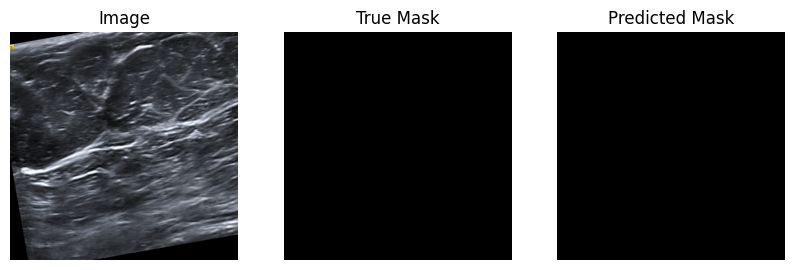

In [ ]:
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

MA_model = smp.MAnet(
    encoder_name="mit_b0",
    encoder_weights=None,
    in_channels=3,
    classes=1
)
MA_model = MA_model.to(device)
MA_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_manet.pth"))

MA_model.eval()
with torch.no_grad():
    img, true_mask, label = MA_train_ds[10]
    img = img.clone()
    true_mask = true_mask.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    input_tensor = img.unsqueeze(0).to(device)
    output = MA_model(input_tensor)
    pred_mask = torch.sigmoid(output[0,0]).cpu().numpy()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores(dataset):
    dice_scores = []
    iou_scores = []

    MA_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = MA_model(input_tensor)
            pred_mask = torch.sigmoid(output)[0, 0].cpu().numpy()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # Compute metrics
            dice = dice_score(pred_bin, true_bin)
            iou = iou_score(pred_bin, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores(MA_train_ds)
print("\nVALIDATION")
predict_scores(MA_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [00:50<00:00, 26.62it/s]


Mean Dice Score: 0.82
Mean IoU Score:  0.77

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:06<00:00, 24.85it/s]

Mean Dice Score: 0.77
Mean IoU Score:  0.71


cuda


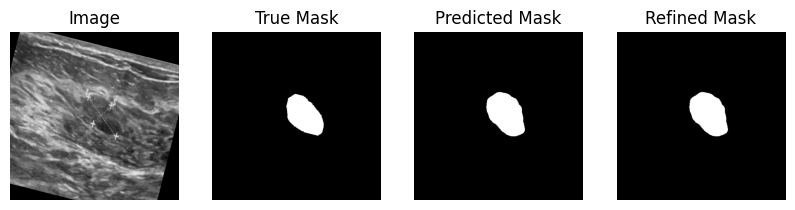

In [ ]:
import segmentation_models_pytorch as smp
from scipy import ndimage as ndi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

MA_model = smp.MAnet(
    encoder_name="mit_b0",
    encoder_weights=None,
    in_channels=3,
    classes=1
)
MA_model = MA_model.to(device)
MA_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_manet.pth"))

MA_model.eval()
with torch.no_grad():
    img, true_mask, label = MA_train_ds[20]
    img = img.clone()
    true_mask = true_mask.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    input_tensor = img.unsqueeze(0).to(device)
    output = MA_model(input_tensor)
    pred_mask = torch.sigmoid(output[0,0]).cpu().numpy()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

# --- Morphological refinement ---
filled_mask = ndi.binary_fill_holes(binary_mask)        # fill internal holes
clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps

refined_mask = clean_mask.astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,4,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(refined_mask, cmap="gray"); plt.title("Refined Mask"); plt.axis("off")
plt.show()

In [ ]:
def predict_scores_new(dataset):
    dice_scores = []
    iou_scores = []

    MA_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = MA_model(input_tensor)
            pred_mask = torch.sigmoid(output)[0, 0].cpu().numpy()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # --- Morphological refinement ---
            filled_mask = ndi.binary_fill_holes(pred_bin)        # fill internal holes
            clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
            clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps
            refined_mask = clean_mask.astype("uint8")

            # Compute metrics
            dice = dice_score(refined_mask, true_bin)
            iou = iou_score(refined_mask, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores_new(MA_train_ds)
print("\nVALIDATION")
predict_scores_new(MA_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [02:03<00:00, 10.99it/s]


Mean Dice Score: 0.82
Mean IoU Score:  0.77

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:12<00:00, 11.93it/s]

Mean Dice Score: 0.77
Mean IoU Score:  0.71


# DeepLabV3
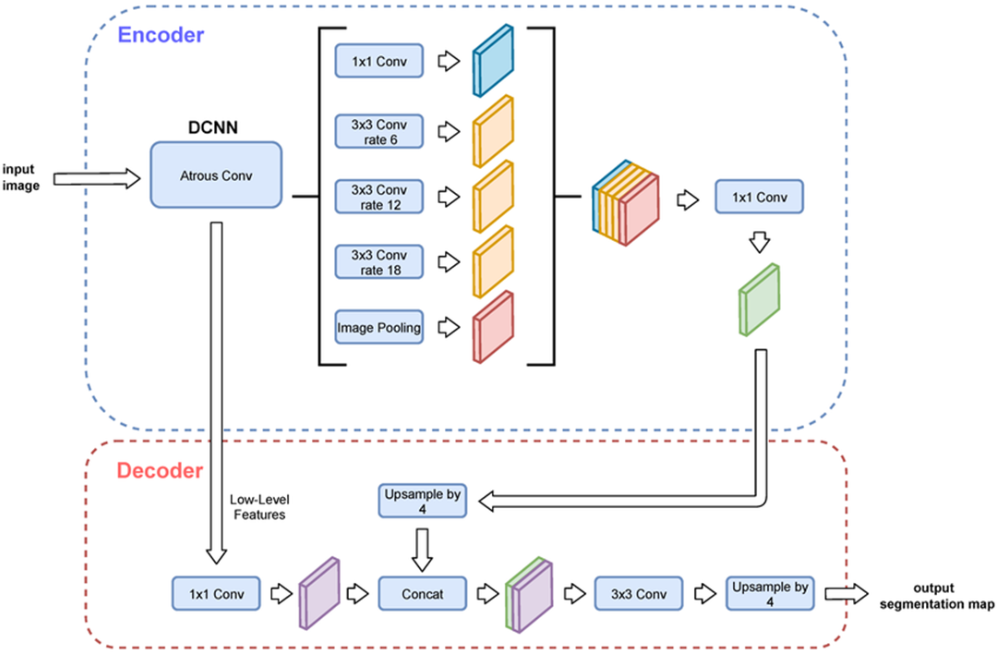

## Dataset preparation

In [ ]:
IMG_SIZE = (224, 224)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
DL_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = train_transform_IN
)

DL_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = val_transform_IN
)


### Create dataloaders

# define batch size
batch_size = 32

DL_train_loader = DataLoader(DL_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
DL_val_loader = DataLoader(DL_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(DL_train_ds)+len(DL_val_ds)}")
print(f"Training set: {len(DL_train_ds)}")
print(f"Validation set: {len(DL_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151


In [ ]:
imgs, masks, labels = next(iter(DL_train_loader))
print(imgs.shape)  # should be (batch_size, C, H, W)
print(masks.shape) # should be (batch_size, C, H, W)


torch.Size([32, 3, 224, 224])
torch.Size([32, 1, 224, 224])


In [ ]:
# 1. Grab a single batch
images, masks,_ = next(iter(DL_train_loader))

# 2. Check statistics
img_min, img_max = images.min().item(), images.max().item()
img_mean, img_std = images.mean().item(), images.std().item()

print(f"Tensor Shape: {images.shape}")
print(f"Data Range:   [{img_min:.3f}, {img_max:.3f}]")
print(f"Mean/Std:     {img_mean:.3f} / {img_std:.3f}")

# 3. Validation Logic
if img_max > 5.0:
    print("STATUS: Raw pixels detected (0-255). No normalization.")
elif img_min >= 0.0 and img_max <= 1.0:
    print("STATUS: 0-1 range detected.")
else:
    print("STATUS: Normalized range detected (Standard for ImageNet).")

Tensor Shape: torch.Size([32, 3, 224, 224])
Data Range:   [-2.118, 2.640]
Mean/Std:     -0.739 / 0.891
STATUS: Normalized range detected (Standard for ImageNet).


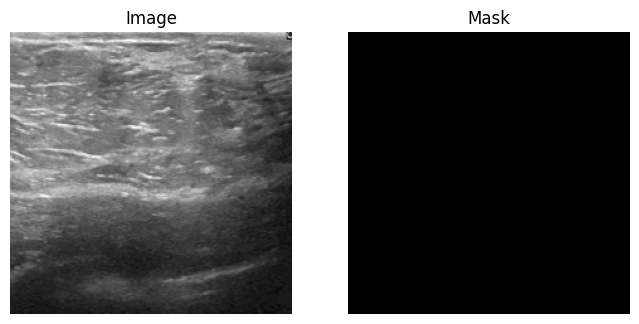

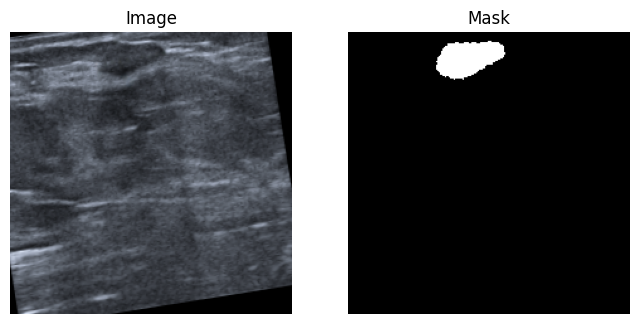

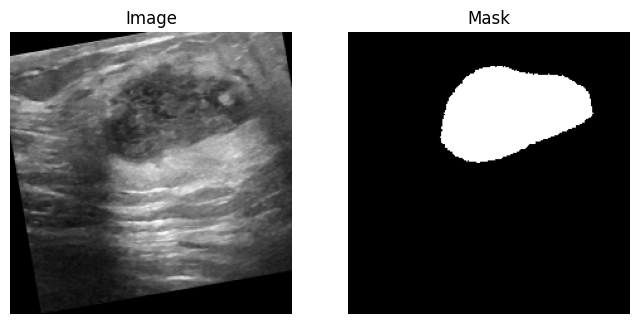

In [ ]:
import matplotlib.pyplot as plt

def show_examples(dataset, n=3):
    for i in range(n):
        img, mask,  label = dataset[i+5]
        for c in range(3):
            img[c] = img[c] * IN_STD[c] + IN_MEAN[c]

        img_np = img.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
        mask_np = mask.squeeze(0).numpy()      # (1,H,W) -> (H,W)

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(img_np)
        ax[0].set_title("Image")
        ax[0].axis('off')

        ax[1].imshow(mask_np, cmap='gray')
        ax[1].set_title("Mask")
        ax[1].axis('off')

        plt.show()

# Show 3 examples from the training dataset
show_examples(DL_train_ds, n=3)


### Model definition

In [ ]:
# Load pretrained DeepLabV3 pre-trained on COCO dataset
seg_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
seg_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
seg_DL_model

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 196MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

### Model training

In [ ]:
# --- Model initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
seg_DL_model = seg_DL_model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(seg_DL_model.parameters(), lr=1e-4)

# --- Scheduler & Early stopping ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
patience = 5
best_val_loss = float("inf")
epochs_no_improve = 0

# --- Training loop ---
n_epochs = 100
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(n_epochs):
    # ---------------- TRAIN ----------------
    seg_DL_model.train()
    train_loss = 0.0
    train_dice = 0.0
    loop = tqdm(DL_train_loader, total=len(DL_train_loader), desc=f"Epoch [{epoch+1}/{n_epochs}]")

    for imgs, masks, label in loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = seg_DL_model(imgs)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coefficient(outputs, masks)

        loop.set_postfix(loss=loss.item(), dice=dice_coefficient(outputs, masks))

    train_loss /= len(DL_train_loader)
    train_dice /= len(DL_train_loader)
    train_losses.append(train_loss)
    train_dices.append(train_dice)

    # ---------------- VALIDATION ----------------
    seg_DL_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, label in DL_val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = seg_DL_model(imgs)["out"]
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks)

    val_loss /= len(DL_val_loader)
    val_dice /= len(DL_val_loader)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    # ---------------- EARLY STOPPING ----------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(seg_DL_model.state_dict(), r"/content/drive/MyDrive/results/best_model_deeplabv3.pth")
        print("💾 Saved new best model.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break


cuda


Epoch [1/100]: 100%|██████████| 43/43 [02:09<00:00,  3.00s/it, dice=0.769, loss=0.344]



Epoch [1/100] | Train Loss: 0.5001 | Train Dice: 0.5351 | Val Loss: 0.5396 | Val Dice: 0.5823
💾 Saved new best model.


Epoch [2/100]: 100%|██████████| 43/43 [02:10<00:00,  3.04s/it, dice=0.548, loss=0.384]



Epoch [2/100] | Train Loss: 0.3184 | Train Dice: 0.7106 | Val Loss: 0.2795 | Val Dice: 0.7085
💾 Saved new best model.


...


Epoch [21/100] | Train Loss: 0.0480 | Train Dice: 0.8747 | Val Loss: 0.0875 | Val Dice: 0.7927
No improvement for 3 epoch(s).


Epoch [22/100]: 100%|██████████| 43/43 [02:10<00:00,  3.02s/it, dice=0.951, loss=0.034]



Epoch [22/100] | Train Loss: 0.0420 | Train Dice: 0.8902 | Val Loss: 0.0775 | Val Dice: 0.7945
No improvement for 4 epoch(s).


Epoch [23/100]: 100%|██████████| 43/43 [02:10<00:00,  3.03s/it, dice=0.894, loss=0.045]



Epoch [23/100] | Train Loss: 0.0391 | Train Dice: 0.9036 | Val Loss: 0.0702 | Val Dice: 0.8029
No improvement for 5 epoch(s).
🛑 Early stopping triggered!


### Model evaluation

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 124MB/s]


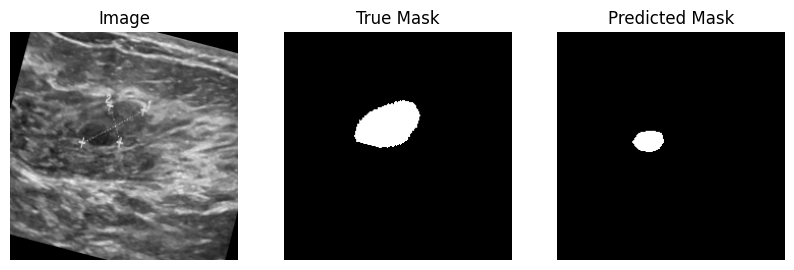

In [ ]:
# Load pretrained DeepLabV3 pre-trained on COCO dataset
seg_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
seg_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
seg_DL_model = seg_DL_model.to(device)
seg_DL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_deeplabv3.pth"))

seg_DL_model.eval()
with torch.no_grad():
    img, true_mask, label = DL_train_ds[20]
    img = img.clone()
    true_mask = true_mask.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    input_tensor = img.unsqueeze(0).to(device)
    output = seg_DL_model(input_tensor)["out"]
    pred_mask = torch.sigmoid(output[0]).cpu().numpy().squeeze()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores(dataset):
    dice_scores = []
    iou_scores = []

    seg_DL_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = seg_DL_model(input_tensor)["out"]
            pred_mask = torch.sigmoid(output)[0].cpu().numpy().squeeze()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # Compute metrics
            dice = dice_score(pred_bin, true_bin)
            iou = iou_score(pred_bin, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores(DL_train_ds)
print("\nVALIDATION")
predict_scores(DL_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [01:09<00:00, 19.51it/s]


Mean Dice Score: 0.88
Mean IoU Score:  0.83

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:07<00:00, 19.52it/s]

Mean Dice Score: 0.78
Mean IoU Score:  0.73


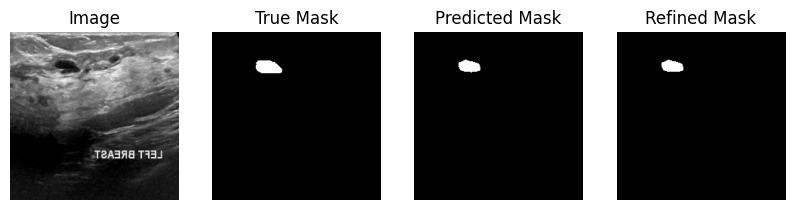

In [ ]:
from scipy import ndimage as ndi

# Load pretrained DeepLabV3 pre-trained on COCO dataset
seg_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
seg_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
seg_DL_model = seg_DL_model.to(device)
seg_DL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_deeplabv3.pth"))

seg_DL_model.eval()
with torch.no_grad():
    img, true_mask, label = DL_train_ds[17]
    img = img.clone()
    true_mask = true_mask.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    input_tensor = img.unsqueeze(0).to(device)
    output = seg_DL_model(input_tensor)["out"]
    pred_mask = torch.sigmoid(output[0]).cpu().numpy().squeeze()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

# --- Morphological refinement ---
filled_mask = ndi.binary_fill_holes(binary_mask)        # fill internal holes
clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps

refined_mask = clean_mask.astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,4,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(refined_mask, cmap="gray"); plt.title("Refined Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores_new(dataset):
    dice_scores = []
    iou_scores = []

    seg_DL_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = seg_DL_model(input_tensor)["out"]
            pred_mask = torch.sigmoid(output)[0].cpu().numpy().squeeze()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # --- Morphological refinement ---
            filled_mask = ndi.binary_fill_holes(pred_bin)        # fill internal holes
            clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
            clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps
            refined_mask = clean_mask.astype("uint8")

            # Compute metrics
            dice = dice_score(refined_mask, true_bin)
            iou = iou_score(refined_mask, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores_new(DL_train_ds)
print("\nVALIDATION")
predict_scores_new(DL_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [01:17<00:00, 17.42it/s]


Mean Dice Score: 0.88
Mean IoU Score:  0.83

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:08<00:00, 18.31it/s]

Mean Dice Score: 0.79
Mean IoU Score:  0.73


# SegFormer
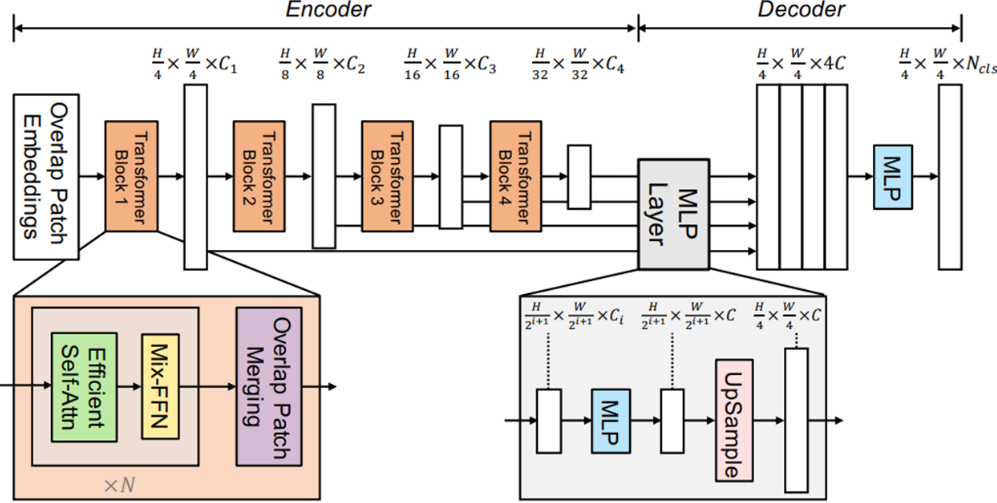

## Dataset preparation

In [ ]:
IMG_SIZE = (512, 512)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


In [ ]:
SF_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform=train_transform_IN
)

SF_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform=val_transform_IN
)

### Create dataloaders

# define batch size
batch_size = 32

SF_train_loader = DataLoader(SF_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
SF_val_loader = DataLoader(SF_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(SF_train_ds)+len(SF_val_ds)}")
print(f"Training set: {len(SF_train_ds)}")
print(f"Validation set: {len(SF_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151


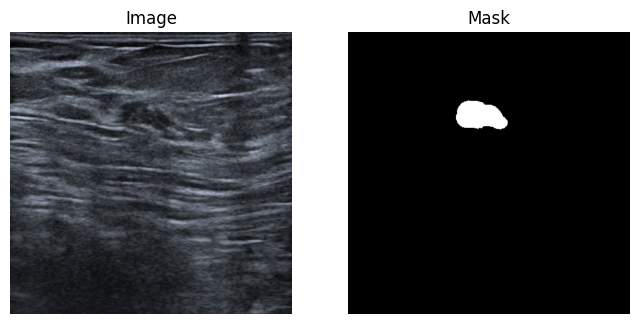

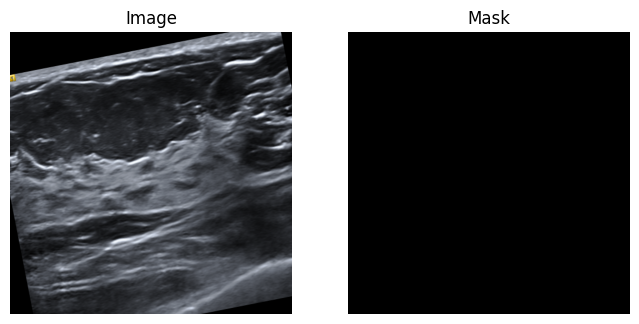

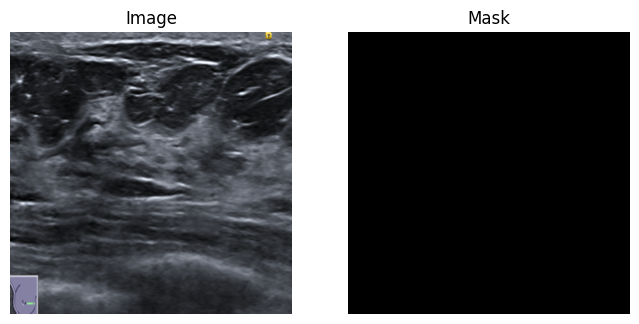

In [ ]:
import matplotlib.pyplot as plt

def show_examples(dataset, n=3):
    for i in range(n):
        img, mask, label = dataset[i]
        for c in range(3):
            img[c] = img[c] * IN_STD[c] + IN_MEAN[c]

        img_np = img.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
        mask_np = mask.squeeze(0).numpy()      # (1,H,W) -> (H,W)

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(img_np)
        ax[0].set_title("Image")
        ax[0].axis('off')

        ax[1].imshow(mask_np, cmap='gray')
        ax[1].set_title("Mask")
        ax[1].axis('off')

        plt.show()

# Show 3 examples from the training dataset
show_examples(SF_train_ds, n=3)


### Model definition

In [ ]:
import segmentation_models_pytorch as smp

SF_model = smp.Segformer(
    encoder_name="mit_b0",        # small, fast Transformer encoder
    encoder_weights="imagenet",   # pretrained weights
    in_channels=3,                # RGB input
    classes=1                     # binary output mask
)

### Model training

In [ ]:
# --- Model initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
SF_model = SF_model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(SF_model.parameters(), lr=1e-4)

# --- Scheduler & Early stopping ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
patience = 5
best_val_loss = float("inf")
epochs_no_improve = 0

# --- Training loop ---
n_epochs = 100
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(n_epochs):
    # ---------------- TRAIN ----------------
    SF_model.train()
    train_loss = 0.0
    train_dice = 0.0
    loop = tqdm(SF_train_loader, total=len(SF_train_loader), desc=f"Epoch [{epoch+1}/{n_epochs}]")

    for imgs, masks, labels in loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = SF_model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coefficient(outputs, masks)

        loop.set_postfix(loss=loss.item(), dice=dice_coefficient(outputs, masks))

    train_loss /= len(SF_train_loader)
    train_dice /= len(SF_train_loader)
    train_losses.append(train_loss)
    train_dices.append(train_dice)

    # ---------------- VALIDATION ----------------
    SF_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, labels in SF_val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = SF_model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks)

    val_loss /= len(SF_val_loader)
    val_dice /= len(SF_val_loader)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    # ---------------- EARLY STOPPING ----------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(SF_model.state_dict(), r"/content/drive/MyDrive/results/best_model_segformer.pth")
        print("💾 Saved new best model.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break


cuda


Epoch [1/100]: 100%|██████████| 43/43 [01:14<00:00,  1.74s/it, dice=0.375, loss=0.194]



Epoch [1/100] | Train Loss: 0.3291 | Train Dice: 0.2329 | Val Loss: 0.3810 | Val Dice: 0.2289
💾 Saved new best model.


Epoch [2/100]: 100%|██████████| 43/43 [01:15<00:00,  1.76s/it, dice=0.25, loss=0.162]



Epoch [2/100] | Train Loss: 0.2154 | Train Dice: 0.3254 | Val Loss: 0.1769 | Val Dice: 0.1792
💾 Saved new best model.


...


Epoch [18/100] | Train Loss: 0.0931 | Train Dice: 0.6774 | Val Loss: 0.0837 | Val Dice: 0.7108
No improvement for 3 epoch(s).


Epoch [19/100]: 100%|██████████| 43/43 [01:15<00:00,  1.76s/it, dice=0.767, loss=0.06]



Epoch [19/100] | Train Loss: 0.0805 | Train Dice: 0.7090 | Val Loss: 0.0923 | Val Dice: 0.7282
No improvement for 4 epoch(s).


Epoch [20/100]: 100%|██████████| 43/43 [01:15<00:00,  1.74s/it, dice=0.925, loss=0.0556]



Epoch [20/100] | Train Loss: 0.0752 | Train Dice: 0.7192 | Val Loss: 0.0851 | Val Dice: 0.7440
No improvement for 5 epoch(s).
🛑 Early stopping triggered!


### Model evaluation

cuda


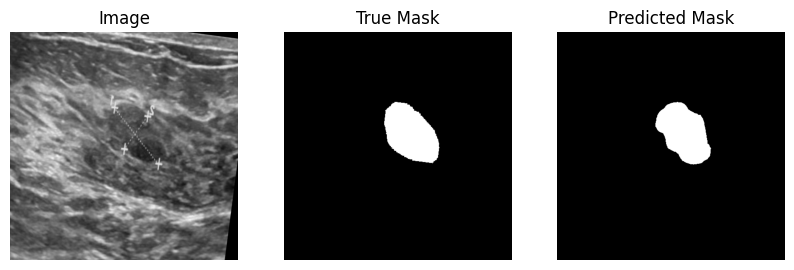

In [ ]:
import segmentation_models_pytorch as smp

SF_model = smp.Segformer(
    encoder_name="mit_b0",        # small, fast Transformer encoder
    encoder_weights="imagenet",   # pretrained weights
    in_channels=3,                # RGB input
    classes=1                     # binary output mask
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

SF_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_segformer.pth"))
SF_model = SF_model.to(device)

SF_model.eval()

with torch.no_grad():
    img, true_mask, label = SF_train_ds[20]
    img = img.clone()
    true_mask = true_mask.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    input_tensor = img.unsqueeze(0).to(device)
    output = SF_model(input_tensor)
    pred_mask = torch.sigmoid(output[0,0]).cpu().numpy()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores(dataset):
    dice_scores = []
    iou_scores = []

    SF_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = SF_model(input_tensor)
            pred_mask = torch.sigmoid(output)[0, 0].cpu().numpy()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # Compute metrics
            dice = dice_score(pred_bin, true_bin)
            iou = iou_score(pred_bin, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores(SF_train_ds)
print("\nVALIDATION")
predict_scores(SF_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [00:49<00:00, 27.52it/s]


Mean Dice Score: 0.74
Mean IoU Score:  0.67

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:04<00:00, 33.07it/s]

Mean Dice Score: 0.73
Mean IoU Score:  0.66


cuda


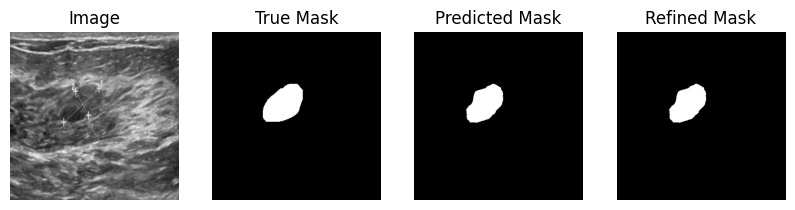

In [ ]:
import segmentation_models_pytorch as smp

SF_model = smp.Segformer(
    encoder_name="mit_b0",        # small, fast Transformer encoder
    encoder_weights="imagenet",   # pretrained weights
    in_channels=3,                # RGB input
    classes=1                     # binary output mask
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

SF_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_segformer.pth"))
SF_model = SF_model.to(device)

SF_model.eval()

with torch.no_grad():
    img, true_mask, label = SF_train_ds[20]
    img = img.clone()
    true_mask = true_mask.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    input_tensor = img.unsqueeze(0).to(device)
    output = SF_model(input_tensor)
    pred_mask = torch.sigmoid(output[0,0]).cpu().numpy()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

# --- Morphological refinement ---
filled_mask = ndi.binary_fill_holes(binary_mask)        # fill internal holes
clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps

refined_mask = clean_mask.astype("uint8")

plt.figure(figsize=(10,4))
plt.subplot(1,4,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(refined_mask, cmap="gray"); plt.title("Refined Mask"); plt.axis("off")
plt.show()

In [ ]:
def predict_scores_new(dataset):
    dice_scores = []
    iou_scores = []

    SF_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = SF_model(input_tensor)
            pred_mask = torch.sigmoid(output)[0, 0].cpu().numpy()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # --- Morphological refinement ---
            filled_mask = ndi.binary_fill_holes(pred_bin)        # fill internal holes
            clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
            clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps
            refined_mask = clean_mask.astype("uint8")

            # Compute metrics
            dice = dice_score(refined_mask, true_bin)
            iou = iou_score(refined_mask, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores_new(SF_train_ds)
print("\nVALIDATION")
predict_scores_new(SF_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [01:48<00:00, 12.41it/s]


Mean Dice Score: 0.75
Mean IoU Score:  0.68

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:12<00:00, 12.53it/s]

Mean Dice Score: 0.73
Mean IoU Score:  0.66


# **1.a. and 1.b. : Classification then Segmentation**

This is the first section really dedicated to solving the 2 tasks given for the project.

This first section will solve the tasks:
* 1.a. : 3-class classification
* 1.b. : 2-class segmentation on the classes B and M predicted by the model from 1.a.

---

To solve these tasks, we will follow this structure:
* Redefine the helper functions
* Create the dataset needed for the classification
* Apply the classification following the model *Transfer-Learning* that was trained previously
* Assess the results of the classification
* Filter the dataset based on the predicted classes
* Train the segmentation model
* Assess the results of the segmentation

---

We first redefine the helper functions. This enables us to start the code from here, without needing to run the sections **Classification** and **Segmentation**.

In [ ]:
def dice_coefficient(preds, targets, smooth=1e-6):
    # preds and targets are torch tensors with shape [B, 1, H, W]
    preds = (preds > 0.5).float()  # binarize predictions
    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean().item()  # mean over batch

def dice_score(pred, target, smooth=1e-6):
    """Computes Dice coefficient for binary masks."""
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    """Computes Intersection over Union (Jaccard index)."""
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

We can import our trained model. This way, we don't have to retrain the chosen model, we can keep the results from the training in the **Classification** section.

In [ ]:
# Recreate the model
TL_model = models.resnet50(weights=None)  # no pretrained weights this time
num_features = TL_model.fc.in_features
TL_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

# Load weights
TL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/transfer_learning.pth", map_location=device))
TL_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Assessment of the Classification model




We start by recreating the dataset with the right normalisation for the *Transfer-Learning* model.

In [ ]:
IMG_SIZE = (224, 224)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


In [ ]:
TL_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = train_transform_IN
)

TL_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = val_transform_IN
)


### Create dataloaders

# define batch size
batch_size = 32

TL_train_loader = DataLoader(TL_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
TL_val_loader = DataLoader(TL_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(TL_train_ds)+len(TL_val_ds)}")
print(f"Training set: {len(TL_train_ds)}")
print(f"Validation set: {len(TL_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151


We can show again the results from the classification with the *Transfer-Learning* model.

In [ ]:
def eval_model(data_loader, model, class_names=class_names):

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, masks, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


    # Visualize it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format=".1f")
    plt.title("Confusion Matrix - Classification")
    plt.show()

    # === Global metrics ===
    accuracy = correct / total

    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_per_class = f1_score(all_labels, all_preds, average=None)

    sensitivity_macro = recall_score(all_labels, all_preds, average='macro')
    sensitivity_weighted = recall_score(all_labels, all_preds, average='weighted')
    sensitivity_per_class = recall_score(all_labels, all_preds, average=None)

    # specificity has no built-in function thus it is computed manually
    specificity_per_class = []
    n_classes = len(class_names)
    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i]) # all elements except the ones on row i and column i
        fp = cm[:, i].sum() - cm[i, i] # column of the class
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    specificity_per_class = np.array(specificity_per_class)
    class_counts = np.bincount(all_labels)
    class_weights = class_counts / class_counts.sum()
    specificity_macro = specificity_per_class.mean()
    specificity_weighted = np.average(specificity_per_class, weights=class_weights)

    # === Display ===
    print("\n=== Global Metrics ===")
    print(f"Accuracy                  : {100 * accuracy:.2f}%")
    print(f"Balanced Accuracy         : {100 * balanced_acc:.2f}%")
    print(f"\nF1-score (Macro)          : {100 * f1_macro:.2f}%")
    print(f"F1-score (Weighted)       : {100 * f1_weighted:.2f}%")
    print(f"\nSensitivity (Macro)       : {100 * sensitivity_macro:.2f}%")
    print(f"Sensitivity (Weighted)    : {100 * sensitivity_weighted:.2f}%")
    print(f"\nSpecificity (Macro)       : {100 * specificity_macro:.2f}%")
    print(f"Specificity (Weighted)    : {100 * specificity_weighted:.2f}%")

    print("\n=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        print(f"{cls:20s} | "
            f"Accuracy: {100 * cm[i, i] / cm[i, :].sum():6.2f}% | "
            f"F1: {100 * f1_per_class[i]:6.2f}% | "
            f"Sensitivity: {100 * sensitivity_per_class[i]:6.2f}% | "
            f"Specificity: {100 * specificity_per_class[i]:6.2f}%")



    print("\n=== True vs Predicted Class Distribution ===")

    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)

    n_classes = len(class_names)

    pred_counts = np.bincount(all_preds_np, minlength=n_classes)
    true_counts = np.bincount(all_labels_np, minlength=n_classes)

    pred_percentages = pred_counts / pred_counts.sum() * 100
    true_percentages = true_counts / true_counts.sum() * 100

    print("\nClass-wise distribution:")
    for i, cls in enumerate(class_names):
        print(
            f"{cls:20s} | "
            f"True: {true_counts[i]:6d} ({true_percentages[i]:6.2f}%) | "
            f"Pred: {pred_counts[i]:6d} ({pred_percentages[i]:6.2f}%)"
        )

    # Plot side-by-side bar chart
    x = np.arange(n_classes)
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, true_counts, width, label="True labels")
    plt.bar(x + width / 2, pred_counts, width, label="Predicted labels")

    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.title("True vs Predicted Class Distribution")
    plt.xticks(x, class_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


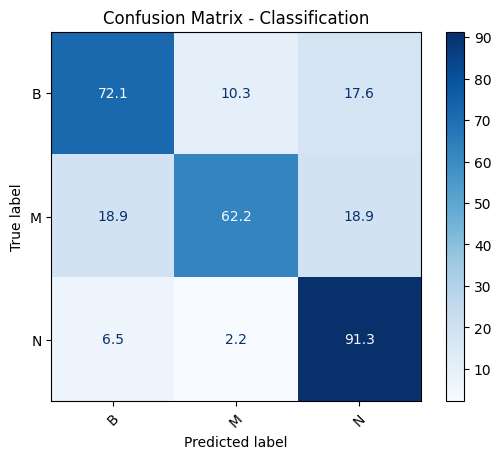


=== Global Metrics ===
Accuracy                  : 75.50%
Balanced Accuracy         : 75.18%

F1-score (Macro)          : 74.44%
F1-score (Weighted)       : 75.24%

Sensitivity (Macro)       : 75.18%
Sensitivity (Weighted)    : 75.50%

Specificity (Macro)       : 87.61%
Specificity (Weighted)    : 87.34%

=== Per-Class Metrics ===
B                    | Accuracy:  72.06% | F1:  77.17% | Sensitivity:  72.06% | Specificity:  87.95%
M                    | Accuracy:  62.16% | F1:  67.65% | Sensitivity:  62.16% | Specificity:  92.98%
N                    | Accuracy:  91.30% | F1:  78.50% | Sensitivity:  91.30% | Specificity:  81.90%

=== True vs Predicted Class Distribution ===

Class-wise distribution:
B                    | True:     68 ( 45.03%) | Pred:     59 ( 39.07%)
M                    | True:     37 ( 24.50%) | Pred:     31 ( 20.53%)
N                    | True:     46 ( 30.46%) | Pred:     61 ( 40.40%)


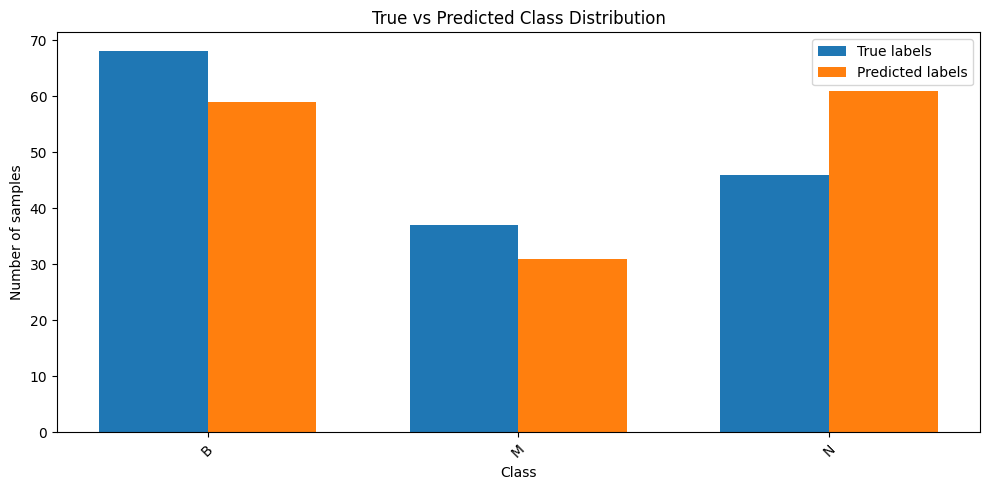

In [ ]:
eval_model(TL_val_loader, TL_model)

## Dataset with the **predicted** classes
We create the function create_predicted_dataset. The goal of this function is:
- get the predictions of one classification model
- keep the images predicted from some chosen classes
- create a dataset (MedicalImageDataset) with these images, their true masks, and their predicted labels

In [ ]:
def create_predicted_dataset(
    model,
    dataloader,
    keep_classes,
    transform
):
    model.eval()

    original_dataset = dataloader.dataset

    # Creation of a temporary dataloader with shuffle=False
    inference_loader = DataLoader(
        original_dataset,
        batch_size=dataloader.batch_size,
        shuffle=False,
        num_workers=dataloader.num_workers,
        pin_memory=dataloader.pin_memory
    )

    kept_image_paths = []
    kept_mask_paths = []
    kept_pred_labels = []

    idx_global = 0

    print("Prediction and filtration...")

    with torch.no_grad():
        for inputs, _, _ in inference_loader:
            device = next(model.parameters()).device
            inputs = inputs.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            batch_size = inputs.size(0)

            for i in range(batch_size):
                pred_label = int(preds[i])

                if pred_label in keep_classes:
                    kept_image_paths.append(original_dataset.image_paths[idx_global])
                    kept_mask_paths.append(original_dataset.mask_paths[idx_global])
                    kept_pred_labels.append(pred_label)

                idx_global += 1

    new_dataset = MedicalImageDataset(
        image_paths=kept_image_paths,
        mask_paths=kept_mask_paths,
        labels=kept_pred_labels,   # predicted labels
        transform=transform
    )

    print(f"Created dataset: {len(new_dataset)} images kept")
    return new_dataset


We will predict the classes with the *Transfer-Learning* model. Then, we will only keep the images from the classes 0 and 1.

In [ ]:
# We only keep the classes 0 and 1
classes_to_keep = [0, 1]

seg_train_dataset = create_predicted_dataset(
    model=TL_model,
    dataloader=TL_train_loader,
    keep_classes=classes_to_keep,
    transform=train_transform_IN
)

seg_val_dataset = create_predicted_dataset(
    model=TL_model,
    dataloader=TL_val_loader,
    keep_classes=classes_to_keep,
    transform=val_transform_IN
)

seg_train_loader = DataLoader(
    seg_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

seg_val_loader = DataLoader(
    seg_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True)


Prediction and filtration...
Created dataset: 838 images kept
Prediction and filtration...
Created dataset: 90 images kept


Now we have 3 datasets, containing the images that were in the **predicted** classes B and M.

In [ ]:
imgs, masks, labels = next(iter(seg_train_loader))
print(imgs.shape)  # should be (batch_size, C, H, W)
print(masks.shape) # should be (batch_size, C, H, W)


torch.Size([32, 3, 224, 224])
torch.Size([32, 1, 224, 224])


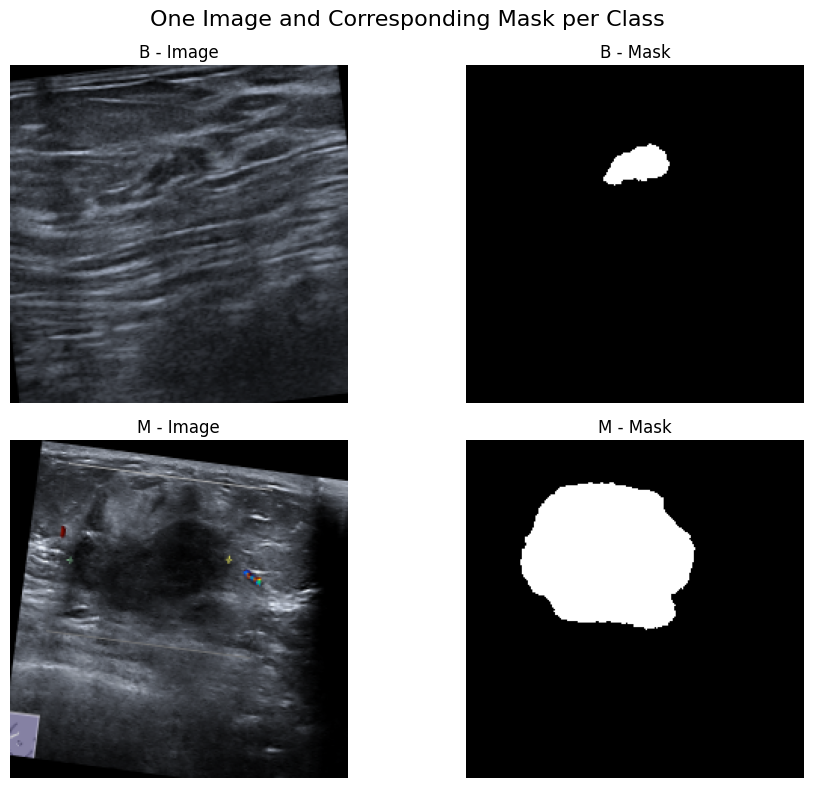

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ["B", "M"]

# Collect one (image, mask) per class
samples_per_class = {}

for img, mask, label in seg_train_dataset:
    cls = class_names[label]
    if cls not in samples_per_class:
        samples_per_class[cls] = (img, mask)
    if len(samples_per_class) == len(class_names):
        break

# Create figure: rows = classes, cols = [image | mask]
fig, axes = plt.subplots(
    nrows=len(class_names),
    ncols=2,
    figsize=(10, 4 * len(class_names))
)

for i, (cls, (img, mask)) in enumerate(samples_per_class.items()):

    # ---- Unnormalize image ----
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * IN_STD[c] + IN_MEAN[c]
    img = img.clamp(0, 1)

    img_np = img.numpy().transpose(1, 2, 0)   # CHW -> HWC
    mask_np = mask.squeeze(0).numpy()          # (H, W)

    # ---- Plot image ----
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{cls} - Image")
    axes[i, 0].axis("off")

    # ---- Plot mask ----
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title(f"{cls} - Mask")
    axes[i, 1].axis("off")

plt.suptitle("One Image and Corresponding Mask per Class", fontsize=16)
plt.tight_layout()
plt.show()


We can now train a segmentation model (here we chose the DeepLabV3 model) with the images with the predicted labels wanted.

## Segmentation

In [ ]:
# Load pretrained DeepLabV3 pre-trained on COCO dataset
CaS_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
CaS_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
CaS_DL_model

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

### Training

In [ ]:
# --- Model initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
CaS_DL_model = CaS_DL_model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(CaS_DL_model.parameters(), lr=1e-4)

# --- Scheduler & Early stopping ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
patience = 10
best_val_loss = float("inf")
epochs_no_improve = 0

# --- Training loop ---
n_epochs = 100
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(n_epochs):
    # ---------------- TRAIN ----------------
    CaS_DL_model.train()
    train_loss = 0.0
    train_dice = 0.0
    loop = tqdm(seg_train_loader, total=len(seg_train_loader), desc=f"Epoch [{epoch+1}/{n_epochs}]")

    for imgs, masks, label in loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = CaS_DL_model(imgs)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coefficient(outputs, masks)

        loop.set_postfix(loss=loss.item(), dice=dice_coefficient(outputs, masks))

    train_loss /= len(seg_train_loader)
    train_dice /= len(seg_train_loader)
    train_losses.append(train_loss)
    train_dices.append(train_dice)

    # ---------------- VALIDATION ----------------
    CaS_DL_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, label in seg_val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = CaS_DL_model(imgs)["out"]
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks)

    val_loss /= len(seg_val_loader)
    val_dice /= len(seg_val_loader)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    # ---------------- EARLY STOPPING ----------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(CaS_DL_model.state_dict(), r"/content/drive/MyDrive/results/best_model_CaS.pth")
        print("💾 Saved new best model.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break



cuda


Epoch [1/100]: 100%|██████████| 26/26 [01:21<00:00,  3.12s/it, dice=0.651, loss=0.398]



Epoch [1/100] | Train Loss: 0.5641 | Train Dice: 0.4124 | Val Loss: 0.8107 | Val Dice: 0.4956
💾 Saved new best model.


Epoch [2/100]: 100%|██████████| 26/26 [01:20<00:00,  3.11s/it, dice=0.724, loss=0.336]



Epoch [2/100] | Train Loss: 0.3724 | Train Dice: 0.6807 | Val Loss: 0.4297 | Val Dice: 0.6664
💾 Saved new best model.


...

Epoch [32/100]: 100%|██████████| 26/26 [01:20<00:00,  3.08s/it, dice=0.925, loss=0.0414]



Epoch [32/100] | Train Loss: 0.0437 | Train Dice: 0.9119 | Val Loss: 0.0983 | Val Dice: 0.8382
No improvement for 2 epoch(s).


Epoch [33/100]: 100%|██████████| 26/26 [01:20<00:00,  3.11s/it, dice=0.926, loss=0.04]



Epoch [33/100] | Train Loss: 0.0428 | Train Dice: 0.9124 | Val Loss: 0.0994 | Val Dice: 0.8326
No improvement for 3 epoch(s).


Epoch [34/100]:   0%|          | 0/26 [00:00<?, ?it/s]

We can now visualise the masks predicted by the model.

## Evaluation of the segmentation

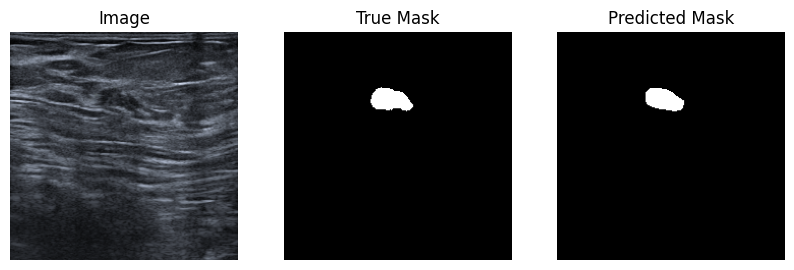

In [ ]:
# Load pretrained DeepLabV3 pre-trained on COCO dataset
CaS_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
CaS_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
CaS_DL_model = CaS_DL_model.to(device)
CaS_DL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_CaS.pth"))

CaS_DL_model.eval()
with torch.no_grad():
    img, true_mask, label = seg_train_dataset[0]
    input_tensor = img.unsqueeze(0).to(device)
    output = CaS_DL_model(input_tensor)["out"]
    pred_mask = torch.sigmoid(output[0]).cpu().numpy().squeeze()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")


def denormalize_imagenet(img_tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return torch.clamp(img, 0, 1)
img_denorm = denormalize_imagenet(img, IN_MEAN, IN_STD)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img_denorm.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores(dataset):
    dice_scores = []
    iou_scores = []

    CaS_DL_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = CaS_DL_model(input_tensor)["out"]
            pred_mask = torch.sigmoid(output)[0].cpu().numpy().squeeze()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # Compute metrics
            dice = dice_score(pred_bin, true_bin)
            iou = iou_score(pred_bin, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---
    print("")
    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores(seg_train_dataset)
print("\nVALIDATION")
predict_scores(seg_val_dataset)

TRAINING


Evaluating: 100%|██████████| 832/832 [00:39<00:00, 21.09it/s]



Mean Dice Score: 0.89
Mean IoU Score:  0.82

VALIDATION


Evaluating: 100%|██████████| 90/90 [00:04<00:00, 20.18it/s]


Mean Dice Score: 0.80
Mean IoU Score:  0.72


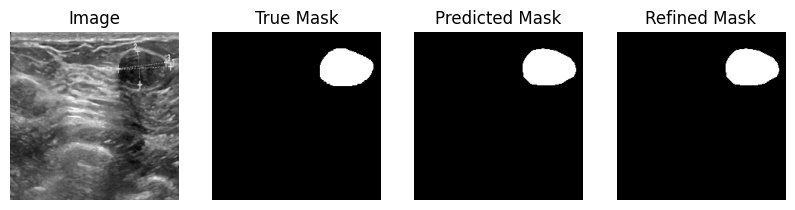

In [ ]:
from scipy import ndimage as ndi

# Load pretrained DeepLabV3 pre-trained on COCO dataset
CaS_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
CaS_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
CaS_DL_model = CaS_DL_model.to(device)
CaS_DL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_CaS.pth"))

CaS_DL_model.eval()
with torch.no_grad():
    img, true_mask, label = seg_train_dataset[10]
    input_tensor = img.unsqueeze(0).to(device)
    output = CaS_DL_model(input_tensor)["out"]
    pred_mask = torch.sigmoid(output[0]).cpu().numpy().squeeze()

# Threshold to binary
binary_mask = (pred_mask > 0.5).astype("uint8")

# --- Morphological refinement ---
filled_mask = ndi.binary_fill_holes(binary_mask)        # fill internal holes
clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps

refined_mask = clean_mask.astype("uint8")

img_denorm = denormalize_imagenet(img) # TEST

plt.figure(figsize=(10,4))
plt.subplot(1,4,1); plt.imshow(img_denorm.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(true_mask.squeeze(), cmap="gray"); plt.title("True Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(binary_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(refined_mask, cmap="gray"); plt.title("Refined Mask"); plt.axis("off")
plt.show()


In [ ]:
def predict_scores_new(dataset):
    dice_scores = []
    iou_scores = []

    CaS_DL_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = CaS_DL_model(input_tensor)["out"]
            pred_mask = torch.sigmoid(output)[0].cpu().numpy().squeeze()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # --- Morphological refinement ---
            filled_mask = ndi.binary_fill_holes(pred_bin)        # fill internal holes
            clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
            clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps
            refined_mask = clean_mask.astype("uint8")

            # Compute metrics
            dice = dice_score(refined_mask, true_bin)
            iou = iou_score(refined_mask, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print("")
    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
print("TRAINING")
predict_scores_new(seg_train_dataset)
print("\nVALIDATION")
predict_scores_new(seg_val_dataset)

TRAINING


Evaluating: 100%|██████████| 832/832 [00:45<00:00, 18.48it/s]



Mean Dice Score: 0.89
Mean IoU Score:  0.82

VALIDATION


Evaluating: 100%|██████████| 90/90 [00:04<00:00, 19.27it/s]


Mean Dice Score: 0.80
Mean IoU Score:  0.72


---
# **2.a. and 2.b. : Segmentation then Classification**

This is the second section dedicated to solving the 2 tasks given for the project.

This second section will solve the tasks:
* 2.a. : 3-class segmentation
* 2.b. : 2-class classification on the classes B and M predicted with the masked images

---

To solve these tasks, we will follow this structure:
* Import the trained *DeepLabV3* model
* Assess the results of the segmentation
* Create the dataset needed for the classification, using the masks predicted with the *DeepLabV3* model
* Train the classification model
* Assess the results of the classification

---


## Assessment of the Segmentation
We import the already trained *DeepLabV3* model

In [ ]:
# Load pretrained DeepLabV3 pre-trained on COCO dataset
seg_DL_model = models.segmentation.deeplabv3_resnet101(weights="COCO_WITH_VOC_LABELS_V1")

# Adjust the classifier head for your number of classes, e.g., binary (1 class) or multi-class segmentation
NUM_CLASSES = 1 # lesion vs. background
seg_DL_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
seg_DL_model = seg_DL_model.to(device)
seg_DL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/best_model_deeplabv3.pth"))

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 107MB/s]


<All keys matched successfully>

We can show again the results from the segmentation with the *DeepLabV3* model.

In [ ]:
from scipy import ndimage as ndi

def predict_scores_new(dataset):
    dice_scores = []
    iou_scores = []

    seg_DL_model.eval()
    with torch.no_grad():
        for img, true_mask, label in tqdm(dataset, desc="Evaluating"):
            # Move image to device
            input_tensor = img.unsqueeze(0).to(device)

            # Forward pass
            output = seg_DL_model(input_tensor)["out"]
            pred_mask = torch.sigmoid(output)[0].cpu().numpy().squeeze()

            # Binarize predictions and ground truth
            pred_bin = (pred_mask > 0.5).astype(np.uint8)
            true_bin = true_mask.squeeze().numpy().astype(np.uint8)

            # --- Morphological refinement ---
            filled_mask = ndi.binary_fill_holes(pred_bin)        # fill internal holes
            clean_mask = ndi.binary_opening(filled_mask, structure=np.ones((3,3)))  # remove small noise
            clean_mask = ndi.binary_closing(clean_mask, structure=np.ones((5,5)))   # close small gaps
            refined_mask = clean_mask.astype("uint8")

            # Compute metrics
            dice = dice_score(refined_mask, true_bin)
            iou = iou_score(refined_mask, true_bin)

            dice_scores.append(dice)
            iou_scores.append(iou)

    # --- PRINT RESULTS ---

    print(f"Mean Dice Score: {np.mean(dice_scores):.2f}")
    print(f"Mean IoU Score:  {np.mean(iou_scores):.2f}")

In [ ]:
IMG_SIZE = (224, 224)

# For classic normalization :
train_transform = get_train_transform(IMG_SIZE, MEAN, STD)
val_transform   = get_val_transform(IMG_SIZE, MEAN, STD)
# For ImageNet normalization :
train_transform_IN = get_train_transform(IMG_SIZE, IN_MEAN, IN_STD)
val_transform_IN   = get_val_transform(IMG_SIZE, IN_MEAN, IN_STD)


In [ ]:
DL_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = train_transform_IN
)

DL_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = val_transform_IN
)


print("TRAINING")
predict_scores_new(DL_train_ds)
print("\nVALIDATION")
predict_scores_new(DL_val_ds)

TRAINING


Evaluating: 100%|██████████| 1352/1352 [01:25<00:00, 15.81it/s]


Mean Dice Score: 0.88
Mean IoU Score:  0.83

VALIDATION


Evaluating: 100%|██████████| 151/151 [00:09<00:00, 16.32it/s]

Mean Dice Score: 0.79
Mean IoU Score:  0.73


We can see that the results are the same as those found in the DeepLabV3 section, which is reassuring.

## Dataset creation with the masked images

In [ ]:
class MaskedTensorDataset(Dataset):
    def __init__(self, images, masks, labels):
        self.images = images      # list of tensors (C,H,W)
        self.masks = masks        # list of tensors (1,H,W)
        self.labels = labels      # list of int

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx], self.labels[idx]


We create the function *create_predicted_segmentation*. The goal of this function is to create a new dataset where the images have been masked with a mask predicted from a chosen segmentation model (here, the DeepLabV3 model trained before).

In [ ]:
def create_predicted_segmentation(
    model,
    dataloader,
    threshold=0.5
):
    model.eval()
    device = next(model.parameters()).device

    masked_images = []
    predicted_masks = []
    labels_out = []

    print("Predicting masks and applying segmentation...")

    with torch.no_grad():
        for inputs, _, labels in dataloader:
            inputs = inputs.to(device)          # (B,3,H,W)
            labels = labels.to(device)

            outputs = model(inputs)["out"]      # (B,1,H,W) or (B,C,H,W)
            preds = torch.sigmoid(outputs)

            for i in range(inputs.size(0)):
                # --- predicted mask ---
                mask = preds[i, 0] > threshold  # (H,W) bool
                mask = mask.float()              # (H,W)

                # --- apply mask ---
                masked_img = inputs[i] * mask.unsqueeze(0)

                masked_images.append(masked_img.cpu())
                predicted_masks.append(mask.unsqueeze(0).cpu())
                labels_out.append(int(labels[i].cpu()))

    new_dataset = MaskedTensorDataset(
        images=masked_images,
        masks=predicted_masks,
        labels=labels_out
    )

    print(f"Created dataset with {len(new_dataset)} masked samples")
    return new_dataset


In [ ]:
TL_train_ds = MedicalImageDataset(
    image_paths=train_imgs,
    mask_paths=train_masks,
    labels=train_labels,
    transform = train_transform_IN
)

TL_val_ds = MedicalImageDataset(
    image_paths=val_imgs,
    mask_paths=val_masks,
    labels=val_labels,
    transform = val_transform_IN
)


### Create dataloaders

# define batch size
batch_size = 32

TL_train_loader = DataLoader(TL_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
TL_val_loader = DataLoader(TL_val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check dimensions
print(f"Total training images: {len(TL_train_ds)+len(TL_val_ds)}")
print(f"Training set: {len(TL_train_ds)}")
print(f"Validation set: {len(TL_val_ds)}")

Total training images: 1503
Training set: 1352
Validation set: 151


In [ ]:
SaC_train_dataset = create_predicted_segmentation(
    model=seg_DL_model,
    dataloader=TL_train_loader
)

SaC_val_dataset = create_predicted_segmentation(
    model=seg_DL_model,
    dataloader=TL_val_loader
)

Predicting masks and applying segmentation...
Created dataset with 1352 masked samples
Predicting masks and applying segmentation...
Created dataset with 151 masked samples


We can now see if the images are masked correctly

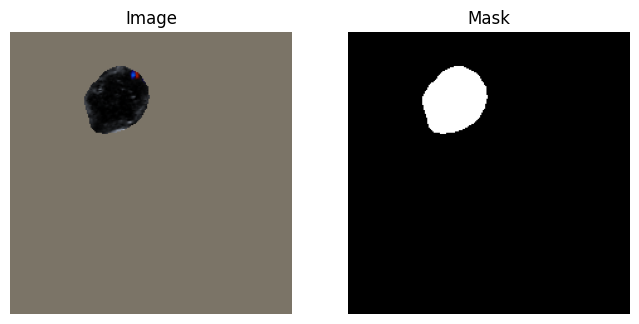

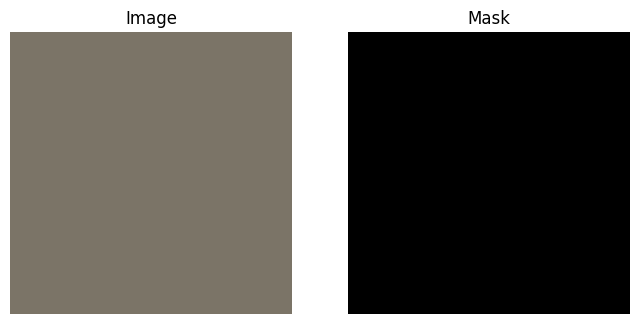

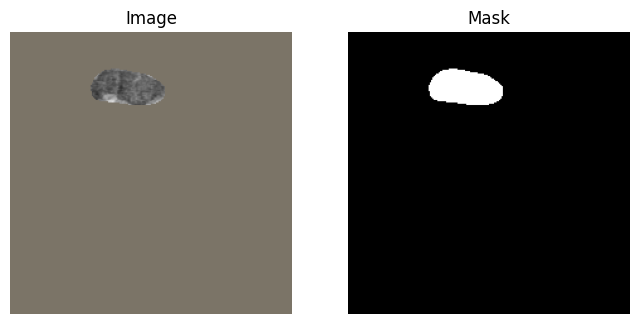

In [ ]:
import matplotlib.pyplot as plt

def show_examples(dataset, n=3):
    for i in range(n):
        img, mask, label = dataset[i+15]

        image_temp = img.clone()
        mask = mask.clone()

        for c in range(3):
            image_temp[c] = image_temp[c] * IN_STD[c] + IN_MEAN[c]

        img_np = image_temp.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
        mask_np = mask.squeeze(0).numpy()      # (1,H,W) -> (H,W)

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(img_np)
        ax[0].set_title("Image")
        ax[0].axis('off')

        ax[1].imshow(mask_np, cmap='gray')
        ax[1].set_title("Mask")
        ax[1].axis('off')

        plt.show()

# Show 3 examples from the training dataset
show_examples(SaC_train_dataset, n=3)


Now, we have dataloaders with masked images. However, we want to do after that a 2-class classifiation, so we have to filter these dataloaders to only keep the 2 classes of interest.

## Filter based on the predicted masks
In this subsection, we divide the images based on the predicted mask. If the predicted mask is completely black, then we will consider the image as normalised, without passing it through a classification model. Then, all the images with a mask non-completely black will be classified by a 2-class classifier.

In [ ]:
train_filtered_indices = [i for i, mask in enumerate(SaC_train_dataset.masks) if torch.any(mask > 0)]
train_normal_indices = [i for i, mask in enumerate(SaC_train_dataset.masks) if not torch.any(mask > 0)]

val_filtered_indices = [i for i, mask in enumerate(SaC_val_dataset.masks) if torch.any(mask > 0)]
val_normal_indices = [i for i, mask in enumerate(SaC_val_dataset.masks) if not torch.any(mask > 0)]



train_filtered_dataset = Subset(SaC_train_dataset, train_filtered_indices)
train_normal_dataset = Subset(SaC_train_dataset, train_normal_indices)
val_filtered_dataset = Subset(SaC_val_dataset, val_filtered_indices)
val_normal_dataset = Subset(SaC_val_dataset, val_normal_indices)

print(f"Number of images in training set (mask not completely black): {len(train_filtered_dataset)}")
print(f"Number of images in training set that were not counted (black mask): {len(train_normal_dataset)}")
print(f"Number of images in validation set (mask not completely black): {len(val_filtered_dataset)}")
print(f"Number of images in validation set that were not counted (black mask): {len(val_normal_dataset)}")

Number of images in training set (mask not completely black): 927
Number of images in training set that were not counted (black mask): 425
Number of images in validation set (mask not completely black): 106
Number of images in validation set that were not counted (black mask): 45


We want to see if this type of filter was effective. Are all the images with a black mask really from the normal class ?

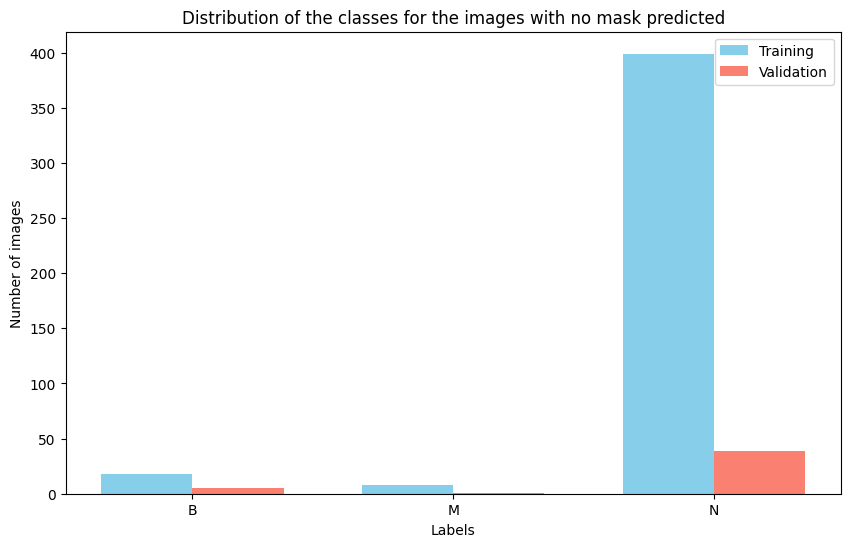

In [ ]:
def plot_label_distribution_two_datasets(dataset1, dataset2, class_names=None, labels_dataset1="Dataset 1", labels_dataset2="Dataset 2"):

    def count_labels(dataset):
        labels = [item[2] for item in dataset]
        counter = Counter(labels)
        sorted_labels = sorted(counter.keys())
        counts = [counter[l] for l in sorted_labels]
        return sorted_labels, counts

    labels1, counts1 = count_labels(dataset1)
    labels2, counts2 = count_labels(dataset2)

    if class_names is None:
        class_names = [str(l) for l in sorted(labels1)]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(10,6))
    plt.bar(x - width/2, counts1, width, label=labels_dataset1, color='skyblue')
    plt.bar(x + width/2, counts2, width, label=labels_dataset2, color='salmon')

    plt.xticks(x, class_names)
    plt.xlabel("Labels")
    plt.ylabel("Number of images")
    plt.title("Distribution of the classes for the images with no mask predicted")
    plt.legend()
    plt.show()

class_names = ["B", "M", "N"]
plot_label_distribution_two_datasets(train_normal_dataset, val_normal_dataset, class_names, "Training", "Validation")

In [ ]:
SaC_train_3class_loader = DataLoader(
    train_filtered_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

SaC_val_3class_loader = DataLoader(
    val_filtered_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

SaC_val_3class_normal_loader = DataLoader(
    val_normal_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True)


In [ ]:
imgs, masks, labels = next(iter(SaC_train_3class_loader))
print(imgs.shape)  # should be (batch_size, C, H, W)
print(masks.shape) # should be (batch_size, C, H, W)


torch.Size([32, 3, 224, 224])
torch.Size([32, 1, 224, 224])


In [ ]:
# 1. Grab a single batch
images, masks,_ = next(iter(SaC_train_3class_loader))

# 2. Check statistics
img_min, img_max = images.min().item(), images.max().item()
img_mean, img_std = images.mean().item(), images.std().item()

print(f"Tensor Shape: {images.shape}")
print(f"Data Range:   [{img_min:.3f}, {img_max:.3f}]")
print(f"Mean/Std:     {img_mean:.3f} / {img_std:.3f}")

# 3. Validation Logic
if img_max > 5.0:
    print("STATUS: Raw pixels detected (0-255). No normalization.")
elif img_min >= 0.0 and img_max <= 1.0:
    print("STATUS: 0-1 range detected.")
else:
    print("STATUS: Normalized range detected (Standard for ImageNet).")

Tensor Shape: torch.Size([32, 3, 224, 224])
Data Range:   [-2.118, 2.640]
Mean/Std:     -0.083 / 0.344
STATUS: Normalized range detected (Standard for ImageNet).


We can now train a classification model (here we chose the Transfer Learning model) with the images with the predicted masks.

### 3-Class Classification

In [ ]:
# Load pretrained ResNet50
SaC_TL_3class_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all convolutional layers
for param in SaC_TL_3class_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_features = SaC_TL_3class_model.fc.in_features
SaC_TL_3class_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 3)
)

SaC_TL_3class_model = SaC_TL_3class_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


In [ ]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(SaC_TL_3class_model.parameters(), lr=0.001)

# Reduce learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
early_stopping_patience = 15
best_val_loss = np.inf
epochs_no_improve = 0

# Max number of epochs
epochs = 100

for epoch in range(epochs):

    # Training
    SaC_TL_3class_model.train()
    running_loss = 0.0

    for inputs, masks, labels in SaC_train_3class_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = SaC_TL_3class_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(SaC_train_3class_loader)

    # Validation
    SaC_TL_3class_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, masks, labels in SaC_val_3class_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = SaC_TL_3class_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / len(SaC_val_3class_loader)
    val_acc = 100 * correct / total

    # Step the scheduler
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = SaC_TL_3class_model.state_dict()  # save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best weights
SaC_TL_3class_model.load_state_dict(best_model_wts)
print("Training complete. Best validation loss:", np.round(best_val_loss, 4))



Epoch [1/100] | Train Loss: 0.7523 | Val Loss: 0.8577 | Val Acc: 65.09%
Epoch [2/100] | Train Loss: 0.6231 | Val Loss: 0.7671 | Val Acc: 67.92%
Epoch [3/100] | Train Loss: 0.5677 | Val Loss: 0.7521 | Val Acc: 71.70%
Epoch [4/100] | Train Loss: 0.5328 | Val Loss: 0.7509 | Val Acc: 70.75%
Epoch [5/100] | Train Loss: 0.5059 | Val Loss: 0.7622 | Val Acc: 68.87%
Epoch [6/100] | Train Loss: 0.4841 | Val Loss: 0.7235 | Val Acc: 72.64%
Epoch [7/100] | Train Loss: 0.4960 | Val Loss: 0.7278 | Val Acc: 70.75%
Epoch [8/100] | Train Loss: 0.4771 | Val Loss: 0.7193 | Val Acc: 71.70%
Epoch [9/100] | Train Loss: 0.4545 | Val Loss: 0.7589 | Val Acc: 69.81%
Epoch [10/100] | Train Loss: 0.4556 | Val Loss: 0.7950 | Val Acc: 66.04%
Epoch [11/100] | Train Loss: 0.4243 | Val Loss: 0.7870 | Val Acc: 67.92%
Epoch [12/100] | Train Loss: 0.4364 | Val Loss: 0.7832 | Val Acc: 66.98%
Epoch [13/100] | Train Loss: 0.4250 | Val Loss: 0.8183 | Val Acc: 69.81%
Epoch [14/100] | Train Loss: 0.3709 | Val Loss: 0.8416 | Val

In [ ]:
# Save best model
torch.save(SaC_TL_3class_model.state_dict(), r"/content/drive/MyDrive/results/transfer_learning_SaC_3class.pth")

### Evaluation of the 3-Class Classification

In [ ]:
# Recreate the model
SaC_TL_3class_model = models.resnet50(weights=None)  # no pretrained weights this time
num_features = SaC_TL_3class_model.fc.in_features
SaC_TL_3class_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 3)
)

# Load weights
SaC_TL_3class_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/transfer_learning_SaC_3class.pth", map_location=device))
SaC_TL_3class_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
def eval_model(data_loader, model, class_names=class_names):

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, masks, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


    # Visualize it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format=".1f")
    plt.title("Confusion Matrix - Classification")
    plt.show()

    # === Global metrics ===
    accuracy = correct / total

    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_per_class = f1_score(all_labels, all_preds, average=None)

    sensitivity_macro = recall_score(all_labels, all_preds, average='macro')
    sensitivity_weighted = recall_score(all_labels, all_preds, average='weighted')
    sensitivity_per_class = recall_score(all_labels, all_preds, average=None)

    # specificity has no built-in function thus it is computed manually
    specificity_per_class = []
    n_classes = len(class_names)
    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i]) # all elements except the ones on row i and column i
        fp = cm[:, i].sum() - cm[i, i] # column of the class
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    specificity_per_class = np.array(specificity_per_class)
    class_counts = np.bincount(all_labels)
    class_weights = class_counts / class_counts.sum()
    specificity_macro = specificity_per_class.mean()
    specificity_weighted = np.average(specificity_per_class, weights=class_weights)

    # === Display ===
    print("\n=== Global Metrics ===")
    print(f"Accuracy                  : {100 * accuracy:.2f}%")
    print(f"Balanced Accuracy         : {100 * balanced_acc:.2f}%")
    print(f"\nF1-score (Macro)          : {100 * f1_macro:.2f}%")
    print(f"F1-score (Weighted)       : {100 * f1_weighted:.2f}%")
    print(f"\nSensitivity (Macro)       : {100 * sensitivity_macro:.2f}%")
    print(f"Sensitivity (Weighted)    : {100 * sensitivity_weighted:.2f}%")
    print(f"\nSpecificity (Macro)       : {100 * specificity_macro:.2f}%")
    print(f"Specificity (Weighted)    : {100 * specificity_weighted:.2f}%")

    print("\n=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        print(f"{cls:20s} | "
            f"Accuracy: {100 * cm[i, i] / cm[i, :].sum():6.2f}% | "
            f"F1: {100 * f1_per_class[i]:6.2f}% | "
            f"Sensitivity: {100 * sensitivity_per_class[i]:6.2f}% | "
            f"Specificity: {100 * specificity_per_class[i]:6.2f}%")



    print("\n=== True vs Predicted Class Distribution ===")

    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)

    n_classes = len(class_names)

    pred_counts = np.bincount(all_preds_np, minlength=n_classes)
    true_counts = np.bincount(all_labels_np, minlength=n_classes)

    pred_percentages = pred_counts / pred_counts.sum() * 100
    true_percentages = true_counts / true_counts.sum() * 100

    print("\nClass-wise distribution:")
    for i, cls in enumerate(class_names):
        print(
            f"{cls:20s} | "
            f"True: {true_counts[i]:6d} ({true_percentages[i]:6.2f}%) | "
            f"Pred: {pred_counts[i]:6d} ({pred_percentages[i]:6.2f}%)"
        )

    # Plot side-by-side bar chart
    x = np.arange(n_classes)
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, true_counts, width, label="True labels")
    plt.bar(x + width / 2, pred_counts, width, label="Predicted labels")

    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.title("True vs Predicted Class Distribution")
    plt.xticks(x, class_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


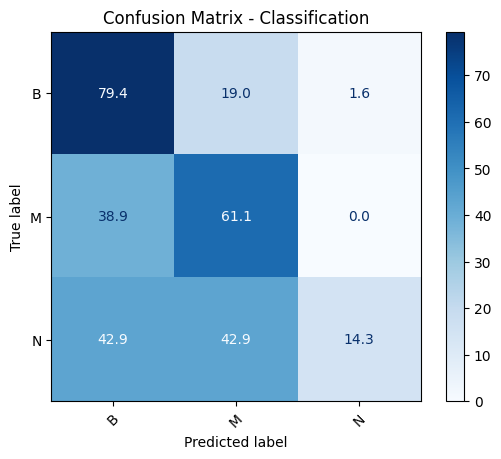


=== Global Metrics ===
Accuracy                  : 68.87%
Balanced Accuracy         : 51.59%

F1-score (Macro)          : 53.14%
F1-score (Weighted)       : 67.66%

Sensitivity (Macro)       : 51.59%
Sensitivity (Weighted)    : 68.87%

Specificity (Macro)       : 79.34%
Specificity (Weighted)    : 69.16%

=== Per-Class Metrics ===
B                    | Accuracy:  79.37% | F1:  76.92% | Sensitivity:  79.37% | Specificity:  60.47%
M                    | Accuracy:  61.11% | F1:  60.27% | Sensitivity:  61.11% | Specificity:  78.57%
N                    | Accuracy:  14.29% | F1:  22.22% | Sensitivity:  14.29% | Specificity:  98.99%

=== True vs Predicted Class Distribution ===

Class-wise distribution:
B                    | True:     63 ( 59.43%) | Pred:     67 ( 63.21%)
M                    | True:     36 ( 33.96%) | Pred:     37 ( 34.91%)
N                    | True:      7 (  6.60%) | Pred:      2 (  1.89%)


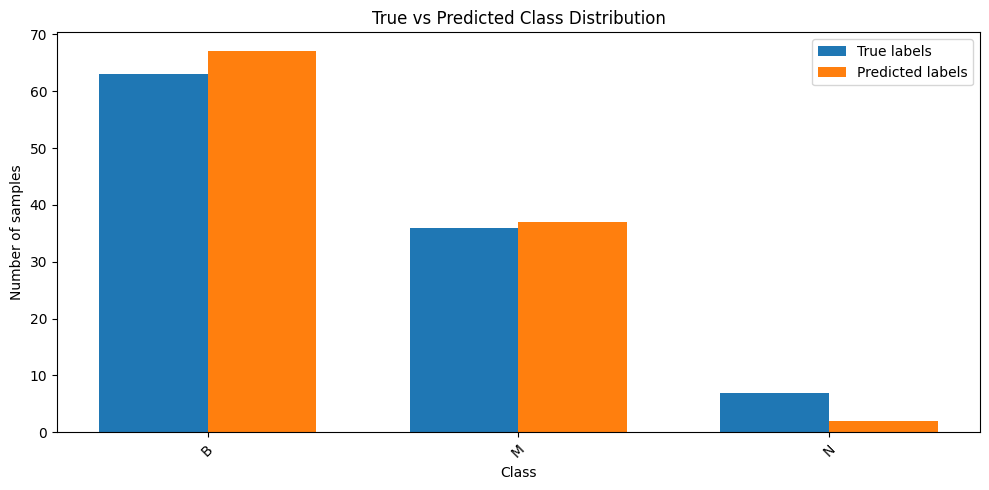

In [ ]:
eval_model(SaC_val_3class_loader, SaC_TL_3class_model)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
    recall_score
)

def eval_model_two_dataloaders(data_loader1, data_loader2, model, class_names, normal_class=2):
    """
    Evaluate a model on two dataloaders:
    - data_loader1 : standard evaluation
    - data_loader2 : all images are assumed predicted as the 'normal_class'

    Args:
        data_loader1 : PyTorch DataLoader
        data_loader2 : PyTorch DataLoader (pre-filtered images)
        model : PyTorch model
        class_names : list of class names
        normal_class : int, index of the 'normal' class
    """
    model.eval()
    all_preds = []
    all_labels = []

    device = next(model.parameters()).device  # Ensure data is on the correct device

    # ==== First dataloader: standard predictions ====
    with torch.no_grad():
        for inputs, masks, labels in data_loader1:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ==== Second dataloader: all images predicted as normal_class ====
    for inputs, masks, labels in data_loader2:
        all_labels.extend(labels.numpy())  # actual labels
        batch_size = labels.size(0)
        all_preds.extend([normal_class] * batch_size)  # all predictions = normal_class

    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)

    # ==== Confusion matrix ====
    cm = confusion_matrix(all_labels_np, all_preds_np)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format=".1f")
    plt.title("Confusion Matrix - Classification")
    plt.show()

    # ==== Global metrics ====
    accuracy = (all_preds_np == all_labels_np).mean()
    balanced_acc = balanced_accuracy_score(all_labels_np, all_preds_np)

    f1_macro = f1_score(all_labels_np, all_preds_np, average='macro')
    f1_weighted = f1_score(all_labels_np, all_preds_np, average='weighted')
    f1_per_class = f1_score(all_labels_np, all_preds_np, average=None)

    sensitivity_macro = recall_score(all_labels_np, all_preds_np, average='macro')
    sensitivity_weighted = recall_score(all_labels_np, all_preds_np, average='weighted')
    sensitivity_per_class = recall_score(all_labels_np, all_preds_np, average=None)

    # Specificity per class
    specificity_per_class = []
    n_classes = len(class_names)
    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))
    specificity_per_class = np.array(specificity_per_class)
    class_counts = np.bincount(all_labels_np)
    class_weights = class_counts / class_counts.sum()
    specificity_macro = specificity_per_class.mean()
    specificity_weighted = np.average(specificity_per_class, weights=class_weights)

    # ==== Display global metrics ====
    print("\n=== Global Metrics ===")
    print(f"Accuracy                  : {100 * accuracy:.2f}%")
    print(f"Balanced Accuracy         : {100 * balanced_acc:.2f}%")
    print(f"\nF1-score (Macro)          : {100 * f1_macro:.2f}%")
    print(f"F1-score (Weighted)       : {100 * f1_weighted:.2f}%")
    print(f"\nSensitivity (Macro)       : {100 * sensitivity_macro:.2f}%")
    print(f"Sensitivity (Weighted)    : {100 * sensitivity_weighted:.2f}%")
    print(f"\nSpecificity (Macro)       : {100 * specificity_macro:.2f}%")
    print(f"Specificity (Weighted)    : {100 * specificity_weighted:.2f}%")

    # ==== Display per-class metrics ====
    print("\n=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        acc_class = 100 * cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
        print(f"{cls:20s} | "
              f"Accuracy: {acc_class:6.2f}% | "
              f"F1: {100 * f1_per_class[i]:6.2f}% | "
              f"Sensitivity: {100 * sensitivity_per_class[i]:6.2f}% | "
              f"Specificity: {100 * specificity_per_class[i]:6.2f}%")

    # ==== True vs Predicted Class Distribution ====
    pred_counts = np.bincount(all_preds_np, minlength=n_classes)
    true_counts = np.bincount(all_labels_np, minlength=n_classes)

    x = np.arange(n_classes)
    width = 0.35
    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, true_counts, width, label="True labels")
    plt.bar(x + width / 2, pred_counts, width, label="Predicted labels")
    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.title("True vs Predicted Class Distribution")
    plt.xticks(x, class_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


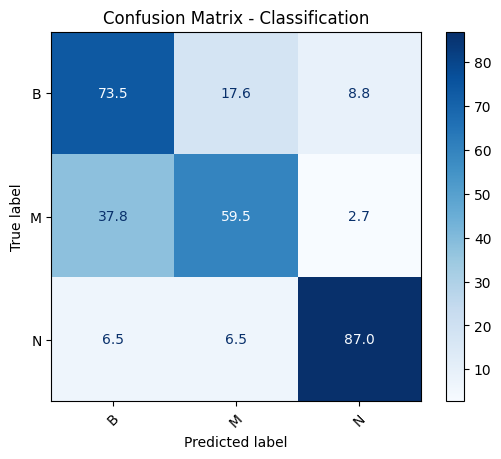


=== Global Metrics ===
Accuracy                  : 74.17%
Balanced Accuracy         : 73.32%

F1-score (Macro)          : 73.19%
F1-score (Weighted)       : 74.13%

Sensitivity (Macro)       : 73.32%
Sensitivity (Weighted)    : 74.17%

Specificity (Macro)       : 86.56%
Specificity (Weighted)    : 85.52%

=== Per-Class Metrics ===
B                    | Accuracy:  73.53% | F1:  74.07% | Sensitivity:  73.53% | Specificity:  79.52%
M                    | Accuracy:  59.46% | F1:  59.46% | Sensitivity:  59.46% | Specificity:  86.84%
N                    | Accuracy:  86.96% | F1:  86.02% | Sensitivity:  86.96% | Specificity:  93.33%


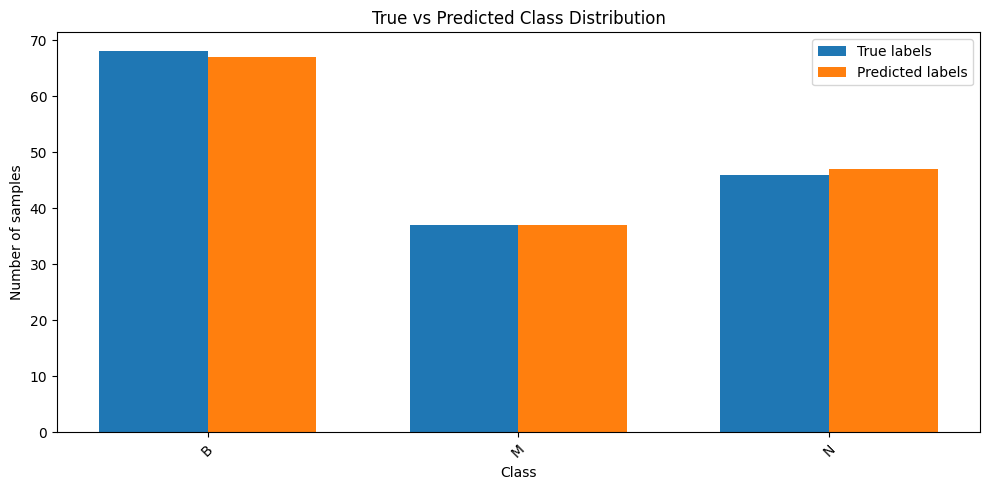

In [ ]:
eval_model_two_dataloaders(SaC_val_3class_loader, SaC_val_3class_normal_loader, SaC_TL_3class_model, class_names)

## Filter based on the predicted masks
In this section, this time the filter is based on the TRUE labels, so the labels given with the dataset. This filer enables us to create a true 2-Class Classification. However, it is a bit cheating, since it is not possible to recreate this method with new data, without annotations.

In [ ]:
SaC_train_loader = DataLoader(
    SaC_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

SaC_val_loader = DataLoader(
    SaC_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [ ]:
def filter_dataloader_by_classes(dataloader, keep_classes, shuffle=True):
    """
    Returns a new DataLoader containing only samples
    whose labels are in keep_classes.
    """

    dataset = dataloader.dataset
    keep_classes = set(keep_classes)

    kept_indices = [
        idx for idx, label in enumerate(dataset.labels)
        if int(label) in keep_classes
    ]

    filtered_dataset = Subset(dataset, kept_indices)

    filtered_loader = DataLoader(
        filtered_dataset,
        batch_size=dataloader.batch_size,
        shuffle=shuffle,
        num_workers=dataloader.num_workers,
        pin_memory=dataloader.pin_memory
    )

    print(
        f"Filtered DataLoader: {len(kept_indices)} samples "
        f"from classes {sorted(keep_classes)}"
    )

    return filtered_loader


In [ ]:
keep_classes = [0,1]

SaC_train_2class_loader = filter_dataloader_by_classes(SaC_train_loader, keep_classes)

SaC_val_2class_loader = filter_dataloader_by_classes(SaC_val_loader, keep_classes)

Filtered DataLoader: 938 samples from classes [0, 1]
Filtered DataLoader: 105 samples from classes [0, 1]


In [ ]:
# 1. Grab a single batch
images, masks,_ = next(iter(SaC_train_2class_loader))

# 2. Check statistics
img_min, img_max = images.min().item(), images.max().item()
img_mean, img_std = images.mean().item(), images.std().item()

print(f"Tensor Shape: {images.shape}")
print(f"Data Range:   [{img_min:.3f}, {img_max:.3f}]")
print(f"Mean/Std:     {img_mean:.3f} / {img_std:.3f}")

# 3. Validation Logic
if img_max > 5.0:
    print("STATUS: Raw pixels detected (0-255). No normalization.")
elif img_min >= 0.0 and img_max <= 1.0:
    print("STATUS: 0-1 range detected.")
else:
    print("STATUS: Normalized range detected (Standard for ImageNet).")

Tensor Shape: torch.Size([32, 3, 224, 224])
Data Range:   [-2.118, 2.640]
Mean/Std:     -0.089 / 0.374
STATUS: Normalized range detected (Standard for ImageNet).


We can now train a classification model (here we chose the Transfer Learning model) with the images with the predicted masks.

### 2-Class Classification

In [ ]:
# Load pretrained ResNet50
SaC_TL_2class_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all convolutional layers
for param in SaC_TL_2class_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_features = SaC_TL_2class_model.fc.in_features
SaC_TL_2class_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

SaC_TL_2class_model = SaC_TL_2class_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 140MB/s]


In [ ]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(SaC_TL_2class_model.parameters(), lr=0.001)

# Reduce learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
early_stopping_patience = 15
best_val_loss = np.inf
epochs_no_improve = 0

# Max number of epochs
epochs = 100

for epoch in range(epochs):

    # Training
    SaC_TL_2class_model.train()
    running_loss = 0.0

    for inputs, masks, labels in SaC_train_2class_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = SaC_TL_2class_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(SaC_train_2class_loader)

    # Validation
    SaC_TL_2class_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, masks, labels in SaC_val_2class_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = SaC_TL_2class_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / len(SaC_val_2class_loader)
    val_acc = 100 * correct / total

    # Step the scheduler
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = SaC_TL_2class_model.state_dict()  # save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best weights
SaC_TL_2class_model.load_state_dict(best_model_wts)
print("Training complete. Best validation loss:", np.round(best_val_loss, 4))



Epoch [1/100] | Train Loss: 0.5905 | Val Loss: 0.5601 | Val Acc: 68.57%
Epoch [2/100] | Train Loss: 0.5203 | Val Loss: 0.5926 | Val Acc: 70.48%
Epoch [3/100] | Train Loss: 0.4808 | Val Loss: 0.5183 | Val Acc: 74.29%
Epoch [4/100] | Train Loss: 0.4424 | Val Loss: 0.4999 | Val Acc: 75.24%
Epoch [5/100] | Train Loss: 0.4536 | Val Loss: 0.4821 | Val Acc: 76.19%
Epoch [6/100] | Train Loss: 0.4306 | Val Loss: 0.4815 | Val Acc: 76.19%
Epoch [7/100] | Train Loss: 0.3921 | Val Loss: 0.5101 | Val Acc: 73.33%
Epoch [8/100] | Train Loss: 0.3965 | Val Loss: 0.4622 | Val Acc: 79.05%
Epoch [9/100] | Train Loss: 0.3890 | Val Loss: 0.5611 | Val Acc: 79.05%
Epoch [10/100] | Train Loss: 0.3919 | Val Loss: 0.5218 | Val Acc: 74.29%
Epoch [11/100] | Train Loss: 0.3619 | Val Loss: 0.4485 | Val Acc: 77.14%
Epoch [12/100] | Train Loss: 0.3540 | Val Loss: 0.5704 | Val Acc: 72.38%
Epoch [13/100] | Train Loss: 0.3599 | Val Loss: 0.4792 | Val Acc: 77.14%
Epoch [14/100] | Train Loss: 0.3250 | Val Loss: 0.5875 | Val

In [ ]:
# Save best model
torch.save(SaC_TL_2class_model.state_dict(), r"/content/drive/MyDrive/results/transfer_learning_SaC_2class.pth")

### Evaluation of the 2-Class Classification

In [ ]:
# Recreate th model
SaC_TL_2class_model = models.resnet50(weights=None)  # no pretrained weights this time
num_features = SaC_TL_2class_model.fc.in_features
SaC_TL_2class_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

# Load weights
SaC_TL_2class_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/transfer_learning_SaC_2class.pth", map_location=device))
SaC_TL_2class_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
def eval_model_binary(data_loader, model, class_names=["0","1"]):

    assert len(class_names) == 2, "Binary evaluation requires exactly 2 classes."

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, masks, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # === Confusion matrix (2x2) ===
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=class_names
    )
    disp.plot(cmap=plt.cm.Blues, values_format=".1f")
    plt.title("Confusion Matrix - Binary Classification")
    plt.show()

    # === Global metrics ===
    accuracy = correct / total
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")
    f1_per_class = f1_score(all_labels, all_preds, average=None)

    sensitivity_per_class = recall_score(all_labels, all_preds, average=None)
    sensitivity_macro = sensitivity_per_class.mean()
    sensitivity_weighted = recall_score(all_labels, all_preds, average="weighted")

    # === Specificity (binary, exact) ===
    tn, fp, fn, tp = cm.ravel()
    specificity_per_class = np.array([
        tn / (tn + fp),
        tp / (tp + fn)
    ])

    class_counts = np.bincount(all_labels, minlength=2)
    class_weights = class_counts / class_counts.sum()

    specificity_macro = specificity_per_class.mean()
    specificity_weighted = np.average(specificity_per_class, weights=class_weights)

    # === Display ===
    print("\n=== Global Metrics ===")
    print(f"Accuracy                  : {100 * accuracy:.2f}%")
    print(f"Balanced Accuracy         : {100 * balanced_acc:.2f}%")
    print(f"\nF1-score (Macro)          : {100 * f1_macro:.2f}%")
    print(f"F1-score (Weighted)       : {100 * f1_weighted:.2f}%")
    print(f"\nSensitivity (Macro)       : {100 * sensitivity_macro:.2f}%")
    print(f"Sensitivity (Weighted)    : {100 * sensitivity_weighted:.2f}%")
    print(f"\nSpecificity (Macro)       : {100 * specificity_macro:.2f}%")
    print(f"Specificity (Weighted)    : {100 * specificity_weighted:.2f}%")

    print("\n=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        print(
            f"{cls:20s} | "
            f"Accuracy: {100 * cm[i, i] / cm[i, :].sum():6.2f}% | "
            f"F1: {100 * f1_per_class[i]:6.2f}% | "
            f"Sensitivity: {100 * sensitivity_per_class[i]:6.2f}% | "
            f"Specificity: {100 * specificity_per_class[i]:6.2f}%"
        )

    # === Distribution ===
    print("\n=== True vs Predicted Class Distribution ===")

    pred_counts = np.bincount(all_preds, minlength=2)
    true_counts = np.bincount(all_labels, minlength=2)

    pred_percentages = pred_counts / pred_counts.sum() * 100
    true_percentages = true_counts / true_counts.sum() * 100

    for i, cls in enumerate(class_names):
        print(
            f"{cls:20s} | "
            f"True: {true_counts[i]:6d} ({true_percentages[i]:6.2f}%) | "
            f"Pred: {pred_counts[i]:6d} ({pred_percentages[i]:6.2f}%)"
        )

    x = np.arange(2)
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, true_counts, width, label="True labels")
    plt.bar(x + width / 2, pred_counts, width, label="Predicted labels")
    plt.xticks(x, class_names, rotation=45)
    plt.ylabel("Number of samples")
    plt.title("True vs Predicted Class Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


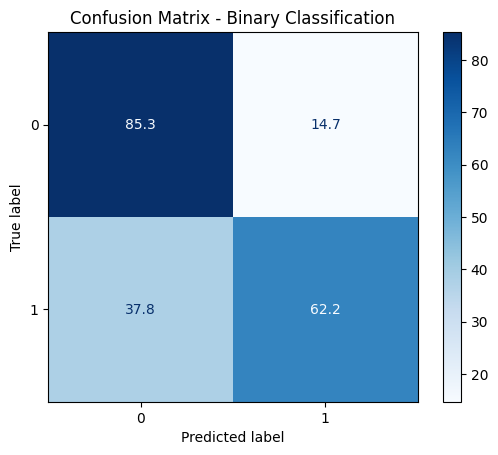


=== Global Metrics ===
Accuracy                  : 77.14%
Balanced Accuracy         : 73.73%

F1-score (Macro)          : 74.29%
F1-score (Weighted)       : 76.82%

Sensitivity (Macro)       : 73.73%
Sensitivity (Weighted)    : 77.14%

Specificity (Macro)       : 73.73%
Specificity (Weighted)    : 77.14%

=== Per-Class Metrics ===
0                    | Accuracy:  85.29% | F1:  82.86% | Sensitivity:  85.29% | Specificity:  85.29%
1                    | Accuracy:  62.16% | F1:  65.71% | Sensitivity:  62.16% | Specificity:  62.16%

=== True vs Predicted Class Distribution ===
0                    | True:     68 ( 64.76%) | Pred:     72 ( 68.57%)
1                    | True:     37 ( 35.24%) | Pred:     33 ( 31.43%)


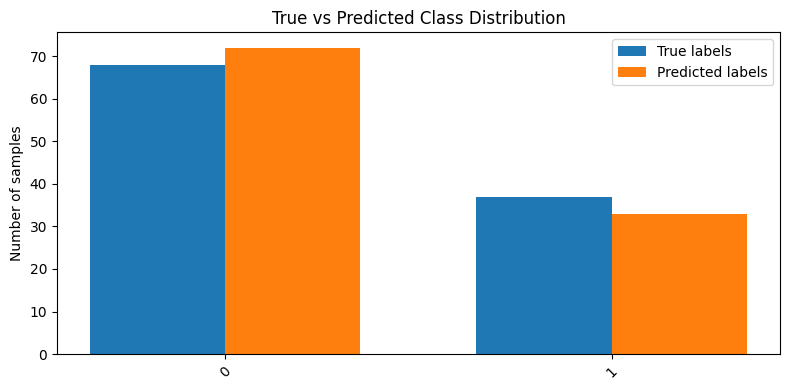

In [ ]:
eval_model_binary(SaC_val_2class_loader, SaC_TL_2class_model)

# **Prediction**
This section is dedicated to the prediction of the test set. Since we don't have the test set yet, we will verify that this section works by using the validation set.

In [ ]:
# We can run this with the right dataset path, for the test set prediction
DRIVE_DATASET_PATH = "/content/drive/MyDrive/Assignment_25_26/training_images/"
LOCAL_DATASET_PATH = "/content/dataset/"

if not os.path.exists(LOCAL_DATASET_PATH):
    print("Copying dataset using rsync (with progress)...")
    !rsync -ah --info=progress2 "$DRIVE_DATASET_PATH" "$LOCAL_DATASET_PATH"
    print("Copy finished.")
else:
    print("Dataset already exists locally.")

In [ ]:
class TestDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(
            Image.open(self.image_paths[idx]).convert("RGB")
        )

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, self.image_paths[idx]


In [ ]:
import glob

test_image_paths = sorted(glob.glob("PATH/TO/TEST_IMAGES/*.png"))
"""
test_dataset = TestDataset(
    image_paths=test_image_paths,
    transform=val_transform_IN
)
"""

# Change this one with the right test set
test_dataset = TestDataset(
    image_paths=image_paths,
    transform=val_transform_IN
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [ ]:
import torch
import pandas as pd
from tqdm import tqdm
import os

def predict_and_create_submission(model, dataloader, device):
    model.eval()
    model.to(device)

    image_names = []
    predicted_labels = []

    with torch.no_grad():
        for images, paths in tqdm(dataloader, desc="Running inference"):
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for p, path in zip(preds, paths):
                image_names.append(os.path.basename(path))
                predicted_labels.append(int(p.cpu().item()))

    submission = pd.DataFrame({
        "US": image_names,
        "LABEL": predicted_labels
    })


    # TEST
    # Extraction des nombres (sans conversion immédiate)
    extracted = submission["US"].str.extract(
        r'^(?:(\d+)_(\d+)|(\d+))\.png$'
    )

    # Colonnes :
    # 0 = main_id (cas 1000_1.png)
    # 1 = sub_id  (cas 1000_1.png)
    # 2 = main_id (cas 1.png)

    submission["main_id"] = extracted[0].fillna(extracted[2])
    submission["sub_id"] = extracted[1].fillna(0)

    # Conversion finale en int (plus de NaN ici)
    submission["main_id"] = submission["main_id"].astype(int)
    submission["sub_id"] = submission["sub_id"].astype(int)

    # Tri hiérarchique
    submission = submission.sort_values(["main_id", "sub_id"])

    # Nettoyage
    submission = submission.drop(columns=["main_id", "sub_id"])


    return submission


In [ ]:
# Recreate the model
TL_model = models.resnet50(weights=None)  # no pretrained weights this time
num_features = TL_model.fc.in_features
TL_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

# Load weights
TL_model.load_state_dict(torch.load(r"/content/drive/MyDrive/results/transfer_learning.pth", map_location=device))
TL_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

submission_df = predict_and_create_submission(
    model=TL_model,          # the trained model
    dataloader=test_loader,
    device=device
)

# submission_df.to_csv("predictions.csv", index=False)

submission_df.to_excel("predictions.xlsx", index=False)

submission_df.head()


Running inference: 100%|██████████| 94/94 [00:30<00:00,  3.13it/s]


,US,LABEL
0,1.png,2
1,2.png,2
2,3.png,2
3,4.png,2
4,5.png,2
